<a href="https://colab.research.google.com/github/Ofir848/A_Student/blob/main/%D7%A8%D7%92%D7%A9%D7%95%D7%AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. חיבור ל-Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. ייבוא ספריות בסיסיות
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Sequential

In [3]:
import zipfile

zip_path = '/content/drive/MyDrive/colab/data/feelings.zip'

# חילוץ לתיקייה מקומית בקולאב (זה לא תופס מקום בדרייב)
local_zip = 'data_emotion'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(local_zip)

print("Extraction complete!")

Extraction complete!


1. בדיקת כמות: האם הדאטה מאוזן?
חשוב לדעת אם יש רגש שיש ממנו המון תמונות ורגש שיש ממנו מעט. אם למשל יש פי 10 תמונות "שמח" מ"פחד", המודל יהיה מוטה לטובת "שמחה".

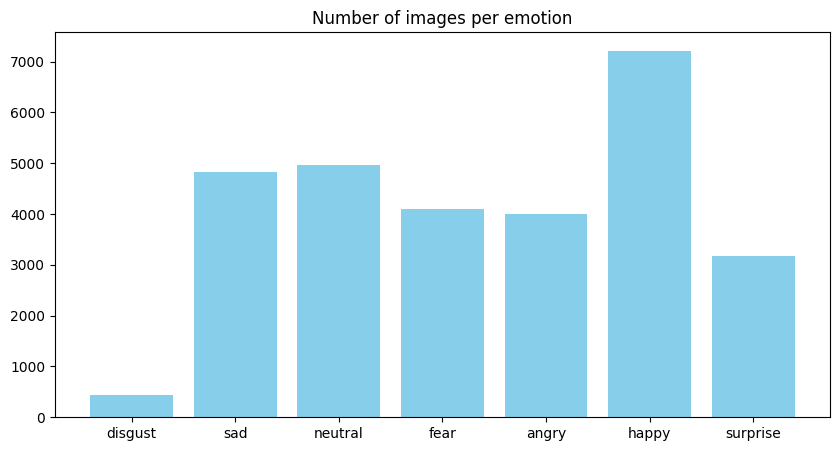

In [ ]:
import matplotlib.pyplot as plt

# נתיב לתיקיית האימון שחילצתי
train_path = 'data_emotion/train'
emotions = os.listdir(train_path)

# ספירה כמה תמונות יש בכל תיקייה
counts = {}
for emotion in emotions:
    counts[emotion] = len(os.listdir(os.path.join(train_path, emotion)))

# יצירת גרף עמודות
plt.figure(figsize=(10, 5))
plt.bar(counts.keys(), counts.values(), color='skyblue')
plt.title('Number of images per emotion')
plt.show()

ניתן לראות שיש התפלגות די טובה בקטגוריות חוץ מבגועל מה שעלול ליצור לנו בעיות בעתיד


 צריך לראות שהחילוץ עבר טוב ושהתמונות אכן ברורות. נציג תמונה אחת מכל רגש:

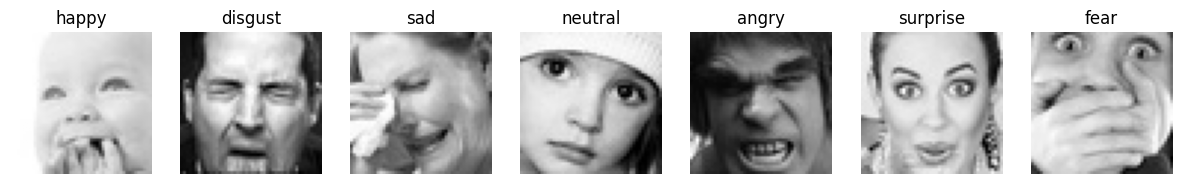

In [ ]:
import matplotlib.image as mpimg

plt.figure(figsize=(15, 10))
for i, emotion in enumerate(emotions):
    # לוקחים את השם של התמונה הראשונה בתיקייה
    img_name = os.listdir(os.path.join(train_path, emotion))[0]
    img_path = os.path.join(train_path, emotion, img_name)

    img = mpimg.imread(img_path)
    plt.subplot(1, 7, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')
plt.show()

בדיקת כפילויות או תמונות פגומות (Quality Check)
כדאי להריץ בדיקה קטנה שמוודאת שאין קבצים שבורים או תמונות שהן רק "ריבוע שחור".

In [ ]:
from PIL import Image

def check_data_quality(root_path):
    bad_images = []
    total_images = 0

    print(f"Starting quality check in: {root_path}")

    for emotion in os.listdir(root_path):
        emotion_path = os.path.join(root_path, emotion)
        if not os.path.isdir(emotion_path):
            continue

        for img_name in os.listdir(emotion_path):
            total_images += 1
            img_path = os.path.join(emotion_path, img_name)

            try:
                # מנסים לפתוח את התמונה ולבדוק את שלמותה
                with Image.open(img_path) as img:
                    img.verify() # בודק אם הקובץ פגום

                # פתיחה מחדש כדי לבדוק גודל (כי verify סוגר את הקובץ)
                with Image.open(img_path) as img:
                    if img.size != (48, 48):
                        bad_images.append((img_path, f"Wrong size: {img.size}"))
            except Exception as e:
                bad_images.append((img_path, str(e)))

    print(f"Finished! Checked {total_images} images.")
    if not bad_images:
        print("✅ All images are healthy and correct size!")
    else:
        print(f"❌ Found {len(bad_images)} problematic images.")
        for path, error in bad_images[:5]: # מציג רק את ה-5 הראשונות
            print(f"File: {path} | Error: {error}")

    return bad_images

# הרצה על תיקיית ה-train וה-test
check_data_quality('data_emotion/train')
check_data_quality('data_emotion/test')

Starting quality check in: data_emotion/train
Finished! Checked 28709 images.
✅ All images are healthy and correct size!
Starting quality check in: data_emotion/test
Finished! Checked 7178 images.
✅ All images are healthy and correct size!


[]

ביצעתי Data Sanitization (ניקוי נתונים) – הרצתי סקריפט שבדק את שלמות הקבצים (Image Integrity) ווידא שכל התמונות עומדות בתקן של 48X48 פיקסלים לפני שלב האימון.

In [4]:
# הגדרת החוקים (כולל חלוקה ל-80% אימון ו-20% בדיקה)
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# צינור האימון
train_generator = datagen.flow_from_directory(
    'data_emotion/train',
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='training'
)

# צינור הבדיקה (Validation)
val_generator = datagen.flow_from_directory(
    'data_emotion/train',
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    subset='validation'
)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


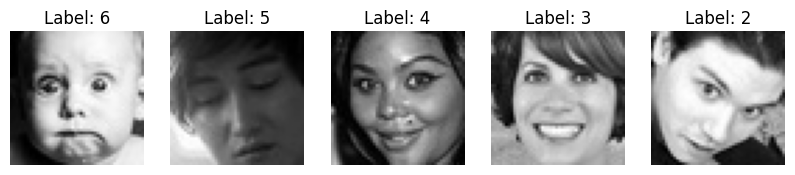

In [ ]:
# שליפת "מנה" אחת של תמונות מהצינור
images, labels = next(train_generator)

# הצגת 5 התמונות הראשונות שהמודל אמור לראות
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].reshape(48, 48), cmap='gray')
    plt.title(f"Label: {labels[i].argmax()}") # מציג את מספר הרגש
    plt.axis('off')
plt.show()

In [5]:
from tensorflow import keras
from tensorflow.keras import layers

In [6]:
#אוגמנטציה בשביך שהגועל לר יעשה הרבה בעיות
def create_augmentation_layer():
    augmentation_layer = keras.Sequential([
        layers.RandomFlip("horizontal"),  # היפוך מראה
        layers.RandomRotation(0.1),     # סיבוב של עד 10%
        layers.RandomZoom(0.1),         # זום קל
    ])
    return augmentation_layer

In [ ]:
# פונקציה פשוטה שבונה מודל לפי רשימת שכבות בלבד
def build_architecture_test(layers_list, name):
    model = keras.Sequential(name=name)

    # שכבות בסיס (קלט, נרמול ואוגמנטציה)
    model.add(layers.Input(shape=(48, 48, 1)))
    model.add(layers.Rescaling(1./255))
    model.add(create_augmentation_layer()) # מוודא שהגדרת את זה קודם

    # שכבות ה-CNN (העיניים של המודל)
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())

    # הוספת השכבות הצפופות (החשיבה) לפי הרשימה שקיבלנו
    for units in layers_list:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(0.2)) # שומרים על דרופאאוט קבוע בינתיים

    # שכבת פלט
    model.add(layers.Dense(7, activation='softmax'))

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# הגדרת המבנים לבדיקה - כל אחד מייצג גישה אחרת
architectures = {
    "The_Classic_Rectangle": [256, 256, 256],    # המבנה המאוזן שאת מכירה
    "The_Wide_Brain": [512, 512],               # מעט שכבות אבל רחבות מאוד (לזכור פרטים)
    "The_Deep_Funnel": [512, 256, 128, 64],     # מבנה "משפך" שמזקק את המידע בהדרגה
    "The_Slim_Deep": [64, 64, 64, 64, 64, 64]   # הרבה שכבות צרות (למציאת קשרים עמוקים)
}

# מילון לשמירת תוצאות
history_results = {}

for name, layout in architectures.items():
    print(f"\n--- בודק מבנה: {name} ---")
    model = build_architecture_test(layout, name)

    # מאמנים ל-5 איטרציות
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=5,
        verbose=1
    )
    # שומרים את הדיוק הכי טוב שהושג בתיקוף
    history_results[name] = max(history.history['val_accuracy'])

print("\n--- סיכום תוצאות השוואת מבנים ---")
# מיון התוצאות מהגבוה לנמוך
sorted_results = sorted(history_results.items(), key=lambda x: x[1], reverse=True)
for name, acc in sorted_results:
    print(f"מודל {name}: דיוק של {acc:.4f}")


--- בודק מבנה: The_Classic_Rectangle ---
Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 79s 212ms/step - accuracy: 0.2493 - loss: 1.8195 - val_accuracy: 0.2513 - val_loss: 1.8124
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 75s 208ms/step - accuracy: 0.2513 - loss: 1.8129 - val_accuracy: 0.2513 - val_loss: 1.8109
Epoch 3/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 75s 208ms/step - accuracy: 0.2513 - loss: 1.8121 - val_accuracy: 0.2513 - val_loss: 1.8108
Epoch 4/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 75s 210ms/step - accuracy: 0.2513 - loss: 1.8120 - val_accuracy: 0.2513 - val_loss: 1.8113
Epoch 5/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 76s 211ms/step - accuracy: 0.2513 - loss: 1.8114 - val_accuracy: 0.2513 - val_loss: 1.8102

--- בודק מבנה: The_Wide_Brain ---
Epoch 1/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 91s 244ms/step - accuracy: 0.2485 - loss: 1.8214 - val_accuracy: 0.2513 - val_loss: 1.8107
Epoch 2/5
359/359 ━━━━━━━━━━━━━━━━━━━━ 141s 241ms/step - accuracy: 0.2513 - loss: 1.8126 - val_accuracy: 0.2513 - val_loss: 1.8132
Epoch 3/5
35

In [ ]:
def build_architecture_test_with_aug(layers_list, name):
    model = keras.Sequential(name=name)

    # 1. שכבת הקלט
    model.add(layers.Input(shape=(48, 48, 1)))

    # 2. נרמול - קריטי!
    model.add(layers.Rescaling(1./255))

    # 3. אוגמנטציה - הוספה מפורשת כאן
    model.add(create_augmentation_layer())

    # 4. שכבות ה-CNN (העיניים)
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())

    # 5. השכבות שאת בודקת
    for units in layers_list:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(0.2))

    model.add(layers.Dense(7, activation='softmax'))

    # שימוש בקצב למידה נמוך יותר כדי למנוע את התקיעה על 0.25
    opt = keras.optimizers.Adam(learning_rate=0.0001)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
print("--- מריצה בדיקה עם אוגמנטציה וקצב למידה נמוך ---")
test_model = build_architecture_test_with_aug([256, 256, 256], "Final_Test")

history = test_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

--- מריצה בדיקה עם אוגמנטציה וקצב למידה נמוך ---
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - accuracy: 0.2487 - loss: 1.8294 - val_accuracy: 0.2513 - val_loss: 1.8118
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 79s 221ms/step - accuracy: 0.2511 - loss: 1.8158 - val_accuracy: 0.2513 - val_loss: 1.8119
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 78s 218ms/step - accuracy: 0.2503 - loss: 1.8160 - val_accuracy: 0.2513 - val_loss: 1.8105
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 234ms/step - accuracy: 0.2512 - loss: 1.8150 - val_accuracy: 0.2513 - val_loss: 1.8100
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 78s 218ms/step - accuracy: 0.2511 - loss: 1.8149 - val_accuracy: 0.2513 - val_loss: 1.8100
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 78s 219ms/step - accuracy: 0.2512 - loss: 1.8134 - val_accuracy: 0.2513 - val_loss: 1.8100
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 85s 235ms/step - accuracy: 0.2514 - loss: 1.8126 - val_accuracy: 0.2513 - val_loss: 1.8113
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━

In [ ]:
def build_final_test_model(layers_list, name):
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(48, 48, 1)))

    # הוספת אוגמנטציה ישירות למודל (מה שעשינו קודם)
    model.add(layers.RandomFlip("horizontal"))
    model.add(layers.RandomRotation(0.1))

    # שכבות ה-CNN הקבועות
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())

    # השכבות המשתנות לפי הניסוי
    for units in layers_list:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(0.3)) # דרופאאוט קבוע לשלב זה

    model.add(layers.Dense(7, activation='softmax'))

    # קצב למידה נמוך כדי להבטיח תזוזה
    opt = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# הגדרת המבנים
test_architectures = {
    "Small_Rectangle": [128, 128],
    "Classic_Rectangle": [256, 256, 256],
    "Deep_Funnel": [512, 256, 128]
}

final_results = {}

for name, layout in test_architectures.items():
    print(f"\n>>> בודק עכשיו: {name}")
    m = build_final_test_model(layout, name)
    history = m.fit(train_generator, validation_data=val_generator, epochs=8)

    # שמירת הדיוק המקסימלי בטריין ובתיקוף להשוואה מלאה
    final_results[name] = {
        "train": max(history.history['accuracy']),
        "val": max(history.history['val_accuracy'])
    }

# הדפסת טבלת השוואה בסיום
print("\n--- סיכום שלב 1 ---")
for name, res in final_results.items():
    print(f"מודל: {name} | דיוק טריין: {res['train']:.3f} | דיוק תיקוף: {res['val']:.3f}")


>>> בודק עכשיו: Small_Rectangle
Epoch 1/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 75s 202ms/step - accuracy: 0.2321 - loss: 1.8426 - val_accuracy: 0.2519 - val_loss: 1.8009
Epoch 2/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 72s 200ms/step - accuracy: 0.2522 - loss: 1.7997 - val_accuracy: 0.2898 - val_loss: 1.7476
Epoch 3/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 84s 205ms/step - accuracy: 0.2813 - loss: 1.7612 - val_accuracy: 0.3435 - val_loss: 1.6983
Epoch 4/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 74s 207ms/step - accuracy: 0.3066 - loss: 1.7268 - val_accuracy: 0.3473 - val_loss: 1.6603
Epoch 5/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 74s 205ms/step - accuracy: 0.3237 - loss: 1.6993 - val_accuracy: 0.3806 - val_loss: 1.6218
Epoch 6/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 81s 202ms/step - accuracy: 0.3372 - loss: 1.6758 - val_accuracy: 0.3816 - val_loss: 1.6014
Epoch 7/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 75s 208ms/step - accuracy: 0.3565 - loss: 1.6475 - val_accuracy: 0.3924 - val_loss: 1.5720
Epoch 8/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 74s 206ms/step - a

In [ ]:
# לוקחים את המבנה המנצח
winning_layout = [512, 256, 128]

optimizers_to_test = {
    "Adam_0.0001": keras.optimizers.Adam(learning_rate=0.0001),
    "SGD_with_Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
}

opt_results = {}

for opt_name, optimizer in optimizers_to_test.items():
    print(f"\n>>> בודק אופטימייזר: {opt_name}")

    # בונים את המודל המנצח שוב לכל אופטימייזר
    model = build_final_test_model(winning_layout, opt_name)
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(train_generator, validation_data=val_generator, epochs=8)
    opt_results[opt_name] = max(history.history['val_accuracy'])

print("\n--- סיכום שלב 2 ---")
for name, acc in opt_results.items():
    print(f"אופטימייזר: {name} | דיוק תיקוף: {acc:.3f}")


>>> בודק אופטימייזר: Adam_0.0001
Epoch 1/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 94s 252ms/step - accuracy: 0.2401 - loss: 1.8314 - val_accuracy: 0.2533 - val_loss: 1.7894
Epoch 2/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 93s 260ms/step - accuracy: 0.2693 - loss: 1.7766 - val_accuracy: 0.3365 - val_loss: 1.7166
Epoch 3/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 251ms/step - accuracy: 0.3076 - loss: 1.7244 - val_accuracy: 0.3585 - val_loss: 1.6294
Epoch 4/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 250ms/step - accuracy: 0.3402 - loss: 1.6667 - val_accuracy: 0.3736 - val_loss: 1.5821
Epoch 5/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 93s 259ms/step - accuracy: 0.3641 - loss: 1.6236 - val_accuracy: 0.3879 - val_loss: 1.5641
Epoch 6/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 91s 253ms/step - accuracy: 0.3805 - loss: 1.5889 - val_accuracy: 0.4123 - val_loss: 1.5275
Epoch 7/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 92s 255ms/step - accuracy: 0.3934 - loss: 1.5547 - val_accuracy: 0.4245 - val_loss: 1.4913
Epoch 8/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 252ms/step - 

In [ ]:
# המנצחים מהשלבים הקודמים
winning_layout = [512, 256, 128]
# כאן הגדרנו רק את קצב הלמידה כמשתנה קבוע
learning_rate_winner = 0.0001

dropout_rates = [0.2, 0.3, 0.5]
dropout_results = {}

for rate in dropout_rates:
    print(f"\n>>> בודק רמת Dropout: {rate}")

    model = keras.Sequential(name=f"Dropout_{rate}")
    model.add(layers.Input(shape=(48, 48, 1)))
    model.add(layers.RandomFlip("horizontal"))
    model.add(layers.RandomRotation(0.1))
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())

    for units in winning_layout:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(rate))

    model.add(layers.Dense(7, activation='softmax'))

    # התיקון: יוצרים אופטימייזר חדש בכל פעם בתוך הלולאה
    current_opt = keras.optimizers.Adam(learning_rate=learning_rate_winner)

    model.compile(optimizer=current_opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(train_generator, validation_data=val_generator, epochs=8)

    dropout_results[rate] = {
        "train": max(history.history['accuracy']),
        "val": max(history.history['val_accuracy'])
    }

# הדפסת הטבלה
print("\n" + "="*40)
print("--- סיכום שלב 3: השוואת Dropout ---")
print(f"{'Dropout Rate':<15} | {'Train Acc':<10} | {'Val Acc':<10}")
print("-" * 40)
for rate, res in dropout_results.items():
    print(f"{rate:<15} | {res['train']:.3f:<10} | {res['val']:.3f:<10}")
print("="*40)


>>> בודק רמת Dropout: 0.2
Epoch 1/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 91s 244ms/step - accuracy: 0.2468 - loss: 1.8276 - val_accuracy: 0.2686 - val_loss: 1.7657
Epoch 2/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 88s 244ms/step - accuracy: 0.2823 - loss: 1.7538 - val_accuracy: 0.3461 - val_loss: 1.6882
Epoch 3/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 92s 258ms/step - accuracy: 0.3299 - loss: 1.6831 - val_accuracy: 0.3674 - val_loss: 1.6344
Epoch 4/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 91s 253ms/step - accuracy: 0.3625 - loss: 1.6327 - val_accuracy: 0.3827 - val_loss: 1.6017
Epoch 5/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 88s 246ms/step - accuracy: 0.3817 - loss: 1.5825 - val_accuracy: 0.4116 - val_loss: 1.5150
Epoch 6/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 88s 246ms/step - accuracy: 0.4022 - loss: 1.5478 - val_accuracy: 0.4240 - val_loss: 1.4887
Epoch 7/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 247ms/step - accuracy: 0.4154 - loss: 1.5150 - val_accuracy: 0.4363 - val_loss: 1.4515
Epoch 8/8
359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 251ms/step - accurac

ValueError: Invalid format specifier '.3f:<10' for object of type 'float'

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

# בניית המודל הסופי לפי המסקנות שלנו
final_model = keras.Sequential(name="Final_Emotion_Model")
final_model.add(layers.Input(shape=(48, 48, 1)))
final_model.add(layers.RandomFlip("horizontal"))
final_model.add(layers.RandomRotation(0.1))

# שכבות קונבולוציה
final_model.add(layers.Conv2D(32, (3, 3), activation='relu'))
final_model.add(layers.MaxPooling2D((2, 2)))
final_model.add(layers.Conv2D(64, (3, 3), activation='relu'))
final_model.add(layers.MaxPooling2D((2, 2)))
final_model.add(layers.Flatten())

# השכבות הצפופות עם ה-Dropout המנצח
for units in [512, 256, 128]:
    final_model.add(layers.Dense(units, activation='relu'))
    final_model.add(layers.Dropout(0.2))

final_model.add(layers.Dense(7, activation='softmax'))

# הגדרת אופטימייזר Adam המנצח
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# שומרים את המודל הכי טוב שנוצר במהלך הריצה
checkpoint = ModelCheckpoint('best_emotion_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# אם המודל מפסיק להשתפר, נוריד את קצב הלמידה עוד קצת כדי "לחפור" לדיוק גבוה
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)

print("\n>>> מתחילים את הריצה הסופית... זה הולך לקחת זמן, לכי לשתות קפה! ☕")
history = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,  # הריצה האמיתית!
    callbacks=[checkpoint, reduce_lr]
)

print("\n--- הריצה הסופית הושלמה! המודל הטוב ביותר נשמר כ-'best_emotion_model.h5' ---")


>>> מתחילים את הריצה הסופית... זה הולך לקחת זמן, לכי לשתות קפה! ☕
Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.2322 - loss: 1.8524

359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 241ms/step - accuracy: 0.2439 - loss: 1.8304 - val_accuracy: 0.2644 - val_loss: 1.7731 - learning_rate: 1.0000e-04
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.2659 - loss: 1.7742

359/359 ━━━━━━━━━━━━━━━━━━━━ 145s 249ms/step - accuracy: 0.2771 - loss: 1.7594 - val_accuracy: 0.3428 - val_loss: 1.6984 - learning_rate: 1.0000e-04
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.3118 - loss: 1.7224

359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 250ms/step - accuracy: 0.3173 - loss: 1.7109 - val_accuracy: 0.3780 - val_loss: 1.6324 - learning_rate: 1.0000e-04
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 93s 259ms/step - accuracy: 0.3460 - loss: 1.6629 - val_accuracy: 0.3701 - val_loss: 1.5999 - learning_rate: 1.0000e-04
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3648 - loss: 1.6257

359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 250ms/step - accuracy: 0.3673 - loss: 1.6163 - val_accuracy: 0.3782 - val_loss: 1.5706 - learning_rate: 1.0000e-04
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.3842 - loss: 1.5845

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 247ms/step - accuracy: 0.5519 - loss: 1.1813 - val_accuracy: 0.5363 - val_loss: 1.2144 - learning_rate: 1.0000e-04
Epoch 34/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 91s 254ms/step - accuracy: 0.5541 - loss: 1.1748 - val_accuracy: 0.5318 - val_loss: 1.2240 - learning_rate: 1.0000e-04
Epoch 35/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5604 - loss: 1.1578

359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 247ms/step - accuracy: 0.5618 - loss: 1.1594 - val_accuracy: 0.5494 - val_loss: 1.2057 - learning_rate: 1.0000e-04
Epoch 36/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 92s 256ms/step - accuracy: 0.5643 - loss: 1.1564 - val_accuracy: 0.5433 - val_loss: 1.2045 - learning_rate: 1.0000e-04
Epoch 37/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 248ms/step - accuracy: 0.5676 - loss: 1.1471 - val_accuracy: 0.5395 - val_loss: 1.2029 - learning_rate: 1.0000e-04
Epoch 38/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 141s 246ms/step - accuracy: 0.5706 - loss: 1.1358 - val_accuracy: 0.5403 - val_loss: 1.1985 - learning_rate: 1.0000e-04
Epoch 39/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 88s 246ms/step - accuracy: 0.5704 - loss: 1.1401 - val_accuracy: 0.5405 - val_loss: 1.1887 - learning_rate: 1.0000e-04
Epoch 40/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 86s 240ms/step - accuracy: 0.5766 - loss: 1.1247 - val_accuracy: 0.5431 - val_loss: 1.2019 - learning_rate: 1.0000e-04
Epoch 41/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 88s 244ms/

359/359 ━━━━━━━━━━━━━━━━━━━━ 142s 248ms/step - accuracy: 0.5987 - loss: 1.0730 - val_accuracy: 0.5523 - val_loss: 1.1786 - learning_rate: 2.0000e-05
Epoch 46/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 249ms/step - accuracy: 0.6060 - loss: 1.0623 - val_accuracy: 0.5501 - val_loss: 1.1825 - learning_rate: 2.0000e-05
Epoch 47/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6087 - loss: 1.0600

359/359 ━━━━━━━━━━━━━━━━━━━━ 141s 246ms/step - accuracy: 0.6090 - loss: 1.0523 - val_accuracy: 0.5537 - val_loss: 1.1808 - learning_rate: 2.0000e-05
Epoch 48/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 247ms/step - accuracy: 0.6096 - loss: 1.0548 - val_accuracy: 0.5532 - val_loss: 1.1802 - learning_rate: 2.0000e-05
Epoch 49/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 90s 250ms/step - accuracy: 0.6100 - loss: 1.0507 - val_accuracy: 0.5520 - val_loss: 1.1836 - learning_rate: 2.0000e-05
Epoch 50/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.6055 - loss: 1.0527

359/359 ━━━━━━━━━━━━━━━━━━━━ 89s 248ms/step - accuracy: 0.6084 - loss: 1.0465 - val_accuracy: 0.5563 - val_loss: 1.1782 - learning_rate: 2.0000e-05

--- הריצה הסופית הושלמה! המודל הטוב ביותר נשמר כ-'best_emotion_model.h5' ---


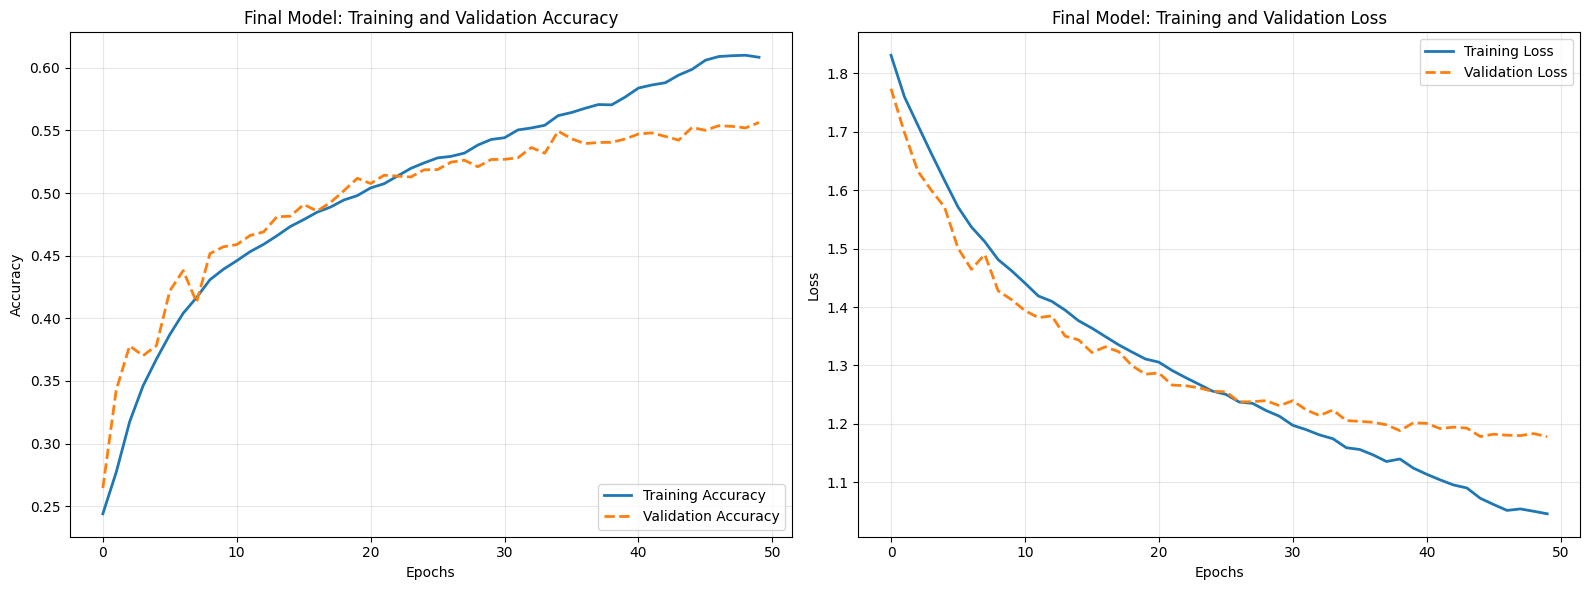


>>> הדיוק הכי גבוה ב-Validation: 0.5563
>>> המודל נשמר בתיקיית הקבצים תחת השם: best_emotion_model.h5


In [ ]:
import matplotlib.pyplot as plt

# פונקציה להצגת גרפים של היסטוריית האימון
def plot_final_results(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # גרף דיוק
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.title('Final Model: Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # גרף הפסד
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.title('Final Model: Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# הרצת הפונקציה על ההיסטוריה של המודל הסופי
plot_final_results(history)

# הדפסת הדיוק הכי גבוה שהגענו אליו בסוף
print(f"\n>>> הדיוק הכי גבוה ב-Validation: {max(history.history['val_accuracy']):.4f}")
print(f">>> המודל נשמר בתיקיית הקבצים תחת השם: best_emotion_model.h5")

ניתן לראות שעברנו לצד החיובי של האחוזי דיוק (מעל 50%) אך עדיין הביצועים אינם מדהימים.

נעשה קוד שמשתמש ב-MobileNetV2 (מודל מוכן מראש). זה ידרוש לשנות את גודל התמונה מ-48 ל-96 פיקסלים, אבל זה הסיכוי הכי טוב לשיפור הביצועים.

In [ ]:
from keras.applications import MobileNetV2
from keras.layers import UpSampling2D, GlobalAveragePooling2D, BatchNormalization, Dense, Dropout, Input, Concatenate
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
import keras

# --- שלב א: הגדרות מקדימות (Callbacks) ---
# אנחנו מגדירים אותם כאן כדי שהם יהיו מוכנים לשימוש לאורך כל התא
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001)
checkpoint = ModelCheckpoint('best_transfer_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# --- שלב ב: בניית המודל ---
input_tensor = Input(shape=(48, 48, 1))
# הגדלת התמונה ל-96x96 כי זה המינימום של MobileNet
x = UpSampling2D(size=(2, 2))(input_tensor)
# שכפול ערוץ השחור-לבן ל-3 ערוצים (כדי שייראה כמו RGB)
x = Concatenate()([x, x, x])

# טעינת המודל המאומן של גוגל
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)

# הקפאת השכבות המקוריות - לא נוגעים בידע הקיים של המודל כרגע
base_model.trainable = False

# הוספת השכבות החדשות שלך (ה"ראש")
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(7, activation='softmax')(x)

tl_model = Model(inputs=input_tensor, outputs=output)

# --- שלב ג: אימון שלב 1 (רק הראש החדש) ---
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(">>> שלב 1: אימון השכבות החדשות בלבד (הקפאה)...")
history_phase1 = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[reduce_lr, checkpoint]
)

# --- שלב ד: אימון שלב 2 (Fine-Tuning - הפשרה) ---
print("\n>>> שלב 2: פתיחת המודל ללמידה עדינה (הפשרה)...")
base_model.trainable = True

# קומפילציה מחדש עם קצב למידה נמוך מאוד כדי לא "להרוס" את המודל המאומן
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[reduce_lr, checkpoint]
)

/tmp/ipykernel_2472/762775840.py:20: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


>>> שלב 1: אימון השכבות החדשות בלבד (הקפאה)...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3275 - loss: 1.8239

359/359 ━━━━━━━━━━━━━━━━━━━━ 59s 110ms/step - accuracy: 0.3680 - loss: 1.6625 - val_accuracy: 0.4187 - val_loss: 1.5049 - learning_rate: 0.0010
Epoch 2/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4325 - loss: 1.4837

359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4296 - loss: 1.4946 - val_accuracy: 0.4388 - val_loss: 1.4725 - learning_rate: 0.0010
Epoch 3/10
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4539 - loss: 1.4262

359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.4496 - loss: 1.4347 - val_accuracy: 0.4510 - val_loss: 1.4475 - learning_rate: 0.0010
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4741 - loss: 1.3714

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.6229 - loss: 0.9642 - val_accuracy: 0.4898 - val_loss: 1.4385 - learning_rate: 1.0000e-05
Epoch 17/20
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6391 - loss: 0.9240

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6386 - loss: 0.9276 - val_accuracy: 0.4914 - val_loss: 1.4174 - learning_rate: 1.0000e-05
Epoch 18/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6549 - loss: 0.8918

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.6528 - loss: 0.8977 - val_accuracy: 0.4976 - val_loss: 1.4248 - learning_rate: 1.0000e-05
Epoch 19/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6651 - loss: 0.8590

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.6628 - loss: 0.8641 - val_accuracy: 0.5032 - val_loss: 1.4291 - learning_rate: 1.0000e-05
Epoch 20/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6760 - loss: 0.8254

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6755 - loss: 0.8269 - val_accuracy: 0.5135 - val_loss: 1.4372 - learning_rate: 1.0000e-05


In [ ]:
from keras.applications import MobileNetV2
from keras.layers import UpSampling2D, GlobalAveragePooling2D, BatchNormalization, Dense, Dropout, Input, Concatenate
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from keras import regularizers
import keras

# 1. הגדרות Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.000001)
checkpoint = ModelCheckpoint('best_robust_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# 2. בניית המודל
input_tensor = Input(shape=(48, 48, 1))
x = UpSampling2D(size=(2, 2))(input_tensor)
x = Concatenate()([x, x, x])

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
base_model.trainable = False  # שלב ראשון: הקפאה

# ה"ראש" המשופר - עם הגנות נגד Overfitting
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

# שכבה ראשונה עם רגולריזציה
x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# שכבה שנייה
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output = Dense(7, activation='softmax')(x)
tl_model = Model(inputs=input_tensor, outputs=output)

# 3. אימון שלב 1 (הקפאה) - 10 איטרציות
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print(">>> מריצים שלב 1: אימון עם 'הגנות'...")
history_p1 = tl_model.fit(train_generator, validation_data=val_generator,
                          epochs=10, callbacks=[reduce_lr, checkpoint])

# 4. אימון שלב 2 (Fine-Tuning) - פתיחת המודל בזהירות
base_model.trainable = True
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print("\n>>> מריצים שלב 2: Fine-Tuning עמוק...")
history_p2 = tl_model.fit(train_generator, validation_data=val_generator,
                          epochs=25, # העליתי ל-25 כדי לתת לרגולריזציה זמן לעבוד
                          callbacks=[reduce_lr, checkpoint])

/tmp/ipykernel_2472/582772218.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


>>> מריצים שלב 1: אימון עם 'הגנות'...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2917 - loss: 10.5838

359/359 ━━━━━━━━━━━━━━━━━━━━ 45s 89ms/step - accuracy: 0.3308 - loss: 8.0161 - val_accuracy: 0.4055 - val_loss: 3.9796 - learning_rate: 0.0010
Epoch 2/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.3913 - loss: 3.4200

359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.3927 - loss: 2.9487 - val_accuracy: 0.4187 - val_loss: 2.2317 - learning_rate: 0.0010
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.4058 - loss: 2.1092 - val_accuracy: 0.4180 - val_loss: 1.9661 - learning_rate: 0.0010
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4109 - loss: 1.9663 - val_accuracy: 0.4160 - val_loss: 1.9174 - learning_rate: 0.0010
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4123 - loss: 1.9425 - val_accuracy: 0.4069 - val_loss: 1.9244 - learning_rate: 0.0010
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.4089 - loss: 1.9400 - val_accuracy: 0.3982 - val_loss: 1.9601 - learning_rate: 0.0010
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.4102 - loss: 1.9385 - val_accuracy: 0.4154 - val_loss: 1.9226 - learning_rate: 0.0010
Epoch 8/10
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4431 - loss: 1.8103

359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.4493 - loss: 1.7602 - val_accuracy: 0.4508 - val_loss: 1.7013 - learning_rate: 2.0000e-04
Epoch 9/10
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4684 - loss: 1.6427

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.5478 - loss: 1.4108 - val_accuracy: 0.4729 - val_loss: 1.5737 - learning_rate: 1.0000e-06
Epoch 21/25
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5532 - loss: 1.4012

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.5514 - loss: 1.4007 - val_accuracy: 0.4790 - val_loss: 1.5671 - learning_rate: 1.0000e-06
Epoch 22/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5495 - loss: 1.4018

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.5560 - loss: 1.3947 - val_accuracy: 0.4818 - val_loss: 1.5621 - learning_rate: 1.0000e-06
Epoch 23/25
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5628 - loss: 1.3847

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.5562 - loss: 1.3871 - val_accuracy: 0.4851 - val_loss: 1.5581 - learning_rate: 1.0000e-06
Epoch 24/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.5621 - loss: 1.3787 - val_accuracy: 0.4839 - val_loss: 1.5548 - learning_rate: 1.0000e-06
Epoch 25/25
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5615 - loss: 1.3769

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.5614 - loss: 1.3775 - val_accuracy: 0.4860 - val_loss: 1.5520 - learning_rate: 1.0000e-06


In [ ]:
# 1. הגדרות Callbacks - החזרנו את ה-patience ל-5 כדי שלא יוריד מהר מדי את ה-LR
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.000001)
checkpoint = ModelCheckpoint('best_sweet_spot_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# 2. בניית המודל (עם ה-L2 המעודכן ל-0.001)
input_tensor = Input(shape=(48, 48, 1))
x = UpSampling2D(size=(2, 2))(input_tensor)
x = Concatenate()([x, x, x])

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

# שכבה ראשונה - רגולריזציה מתונה יותר (0.001)
x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# שכבה שנייה - רגולריזציה מתונה יותר (0.001)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

output = Dense(7, activation='softmax')(x)
tl_model = Model(inputs=input_tensor, outputs=output)

# 3. שלב 1: אימון הראש (10 איטרציות)
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print(">>> מריצים שלב 1: אימון ראש עם רגולריזציה מתונה...")
history_p1 = tl_model.fit(train_generator, validation_data=val_generator,
                          epochs=10, callbacks=[reduce_lr, checkpoint])

# 4. שלב 2: Fine-Tuning (40 איטרציות)
base_model.trainable = True
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print("\n>>> מריצים שלב 2: Fine-Tuning ממושך לדיוק מקסימלי...")
history_p2 = tl_model.fit(train_generator, validation_data=val_generator,
                          epochs=40, callbacks=[reduce_lr, checkpoint])

/tmp/ipykernel_2472/440107951.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


>>> מריצים שלב 1: אימון ראש עם רגולריזציה מתונה...
Epoch 1/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2885 - loss: 3.3898

359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 65ms/step - accuracy: 0.3301 - loss: 3.0679 - val_accuracy: 0.4247 - val_loss: 2.4924 - learning_rate: 0.0010
Epoch 2/10
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4027 - loss: 2.5446

359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4102 - loss: 2.4618 - val_accuracy: 0.4412 - val_loss: 2.2341 - learning_rate: 0.0010
Epoch 3/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4455 - loss: 2.1870

359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4351 - loss: 2.1577 - val_accuracy: 0.4466 - val_loss: 2.0268 - learning_rate: 0.0010
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.4525 - loss: 1.9604 - val_accuracy: 0.4419 - val_loss: 1.9102 - learning_rate: 0.0010
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4676 - loss: 1.8456

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.5934 - loss: 1.3814 - val_accuracy: 0.4980 - val_loss: 1.6164 - learning_rate: 1.0000e-06
Epoch 33/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5993 - loss: 1.3795

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.5954 - loss: 1.3815 - val_accuracy: 0.4987 - val_loss: 1.6154 - learning_rate: 1.0000e-06
Epoch 34/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6036 - loss: 1.3640

359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.6026 - loss: 1.3689 - val_accuracy: 0.5006 - val_loss: 1.6139 - learning_rate: 1.0000e-06
Epoch 35/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6011 - loss: 1.3681 - val_accuracy: 0.5006 - val_loss: 1.6122 - learning_rate: 1.0000e-06
Epoch 36/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5984 - loss: 1.3663

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6045 - loss: 1.3628 - val_accuracy: 0.5015 - val_loss: 1.6109 - learning_rate: 1.0000e-06
Epoch 37/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.6071 - loss: 1.3551 - val_accuracy: 0.5008 - val_loss: 1.6097 - learning_rate: 1.0000e-06
Epoch 38/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.6071 - loss: 1.3485 - val_accuracy: 0.5011 - val_loss: 1.6090 - learning_rate: 1.0000e-06
Epoch 39/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.6125 - loss: 1.3435

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6128 - loss: 1.3435 - val_accuracy: 0.5030 - val_loss: 1.6081 - learning_rate: 1.0000e-06
Epoch 40/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.6144 - loss: 1.3367 - val_accuracy: 0.5027 - val_loss: 1.6069 - learning_rate: 1.0000e-06


ניתוח המצב (התמונה המלאה)
שיפור ב-Validation: עלינו מ-48.6% ל-50.2%. זה כיוון חיובי, אבל זה עדיין לא ה-60% שקיווינו לו.

צמצום ה-Overfitting: הפער בין ה-Train (61%) ל-Val (50%) הוא עכשיו 11%. זה הרבה יותר טוב מה-16% שהיו לנו בהתחלה, אבל המודל עדיין "מעדיף" לשנן את תמונות האימון.

ה-Learning Rate "מת": שמתי לב שבשני המודלים האחרונים, בסוף השלב השני, ה-Learning Rate הגיע ל-1.0000e-06. זה אומר שהצעדים של המודל כל כך קטנים שהוא פשוט הפסיק ללמוד באמצע הדרך.

למה זה קורה?
התמונות ב-FER2013 הן מאוד קטנות (48x48) ומלאות ב"רעש". כשמגדילים אותן ל-96x96 עבור MobileNet, הן הופכות למטושטשות. המודל מנסה למצוא "רמזים" בטשטוש הזה במקום בתווי הפנים האמיתיים.

ביטול ה-L2 בשכבה השנייה: נשאיר רגולריזציה רק בשכבה הראשונה. זה ייתן למודל יותר "גמישות" ללמוד רגשות מורכבים.

העלאת ה-Learning Rate המינימלי: נכריח את המודל להמשיך לצעוד ולא לעצור ב-1e-06.

שימוש ב-GlobalMaxPooling: לפעמים בתוך טשטוש, עדיף לקחת את הפיקסל הכי חזק (Max) מאשר את הממוצע (Average).

In [ ]:
# שינוי קטן ב-Callbacks - לא נותנים ל-LR לרדת מתחת ל-1e-05
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=0.00001)
checkpoint = ModelCheckpoint('final_best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

# בניית המודל
input_tensor = Input(shape=(48, 48, 1))
x = UpSampling2D(size=(2, 2))(input_tensor)
x = Concatenate()([x, x, x])

base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)
base_model.trainable = False

x = base_model.output
x = layers.GlobalMaxPooling2D()(x) # שינוי ל-Max Pooling
x = BatchNormalization()(x)

# שכבה 1 - עם הגנה
x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

# שכבה 2 - חופשייה יותר (בלי L2)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(7, activation='softmax')(x)
tl_model = Model(inputs=input_tensor, outputs=output)

# אימון שלב 1 ושלב 2 כרגיל (כמו בקוד הקודם)
# 3. שלב 1: אימון הראש (10 איטרציות)
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print(">>> מריצים שלב 1: אימון ראש עם רגולריזציה מתונה...")
history_p1 = tl_model.fit(train_generator, validation_data=val_generator,
                          epochs=10, callbacks=[reduce_lr, checkpoint])

# 4. שלב 2: Fine-Tuning (40 איטרציות)
base_model.trainable = True
tl_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.00001),
                 loss='categorical_crossentropy', metrics=['accuracy'])

print("\n>>> מריצים שלב 2: Fine-Tuning ממושך לדיוק מקסימלי...")
history_p2 = tl_model.fit(train_generator, validation_data=val_generator,
                          epochs=40, callbacks=[reduce_lr, checkpoint])

/tmp/ipykernel_2472/58934172.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=x)


>>> מריצים שלב 1: אימון ראש עם רגולריזציה מתונה...
Epoch 1/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.2983 - loss: 2.5605

359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 72ms/step - accuracy: 0.3386 - loss: 2.2966 - val_accuracy: 0.4254 - val_loss: 1.8854 - learning_rate: 0.0010
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4037 - loss: 1.9389

359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.4083 - loss: 1.9027 - val_accuracy: 0.4386 - val_loss: 1.7861 - learning_rate: 0.0010
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.4428 - loss: 1.7648 - val_accuracy: 0.4367 - val_loss: 1.7268 - learning_rate: 0.0010
Epoch 4/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4661 - loss: 1.6766

359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.4616 - loss: 1.6743 - val_accuracy: 0.4546 - val_loss: 1.6677 - learning_rate: 0.0010
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.4655 - loss: 1.6246 - val_accuracy: 0.4546 - val_loss: 1.6539 - learning_rate: 0.0010
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4884 - loss: 1.5661

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.7263 - loss: 0.9667 - val_accuracy: 0.5095 - val_loss: 1.5348 - learning_rate: 1.0000e-05
Epoch 20/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7470 - loss: 0.9211

359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.7426 - loss: 0.9297 - val_accuracy: 0.5156 - val_loss: 1.5298 - learning_rate: 1.0000e-05
Epoch 21/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7618 - loss: 0.8913

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.7580 - loss: 0.8959 - val_accuracy: 0.5198 - val_loss: 1.5261 - learning_rate: 1.0000e-05
Epoch 22/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.7689 - loss: 0.8599 - val_accuracy: 0.5152 - val_loss: 1.5447 - learning_rate: 1.0000e-05
Epoch 23/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7837 - loss: 0.8230

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.7800 - loss: 0.8266 - val_accuracy: 0.5226 - val_loss: 1.5487 - learning_rate: 1.0000e-05
Epoch 24/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.7957 - loss: 0.7840 - val_accuracy: 0.5210 - val_loss: 1.5661 - learning_rate: 1.0000e-05
Epoch 25/40
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8116 - loss: 0.7529

359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.8086 - loss: 0.7554 - val_accuracy: 0.5295 - val_loss: 1.5833 - learning_rate: 1.0000e-05
Epoch 26/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8229 - loss: 0.7198 - val_accuracy: 0.5262 - val_loss: 1.5994 - learning_rate: 1.0000e-05
Epoch 27/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.8360 - loss: 0.6831 - val_accuracy: 0.5222 - val_loss: 1.6176 - learning_rate: 1.0000e-05
Epoch 28/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.8423 - loss: 0.6583 - val_accuracy: 0.5240 - val_loss: 1.6337 - learning_rate: 1.0000e-05
Epoch 29/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.8533 - loss: 0.6314 - val_accuracy: 0.5250 - val_loss: 1.6469 - learning_rate: 1.0000e-05
Epoch 30/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8641 - loss: 0.6037 - val_accuracy: 0.5280 - val_loss: 1.6648 - learning_rate: 1.0000e-05
Epoch 31/40
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - a

מצד אחד, זה מדהים – הצלחנו לגרום למודל "להבין" כמעט כל תמונה בסט האימון. מצד שני, ה-Validation נשאר מאחור על 52.7%. זה ה-Overfitting הכי קיצוני שראינו עד עכשיו.

הסיבה פשוטה: MobileNetV2 פשוט "חכם" מדי עבור הדאטה הזה. הוא כל כך חזק שהוא מצליח לשנן את הפיקסלים הספציפיים של כל תמונה (93%!), אבל כשהוא פוגש תמונה חדשה, הוא הולך לאיבוד. הגענו ל"תקרת זכוכית" עם המודל הזה.

במקום לנסות "לאלף" מודל ענק של גוגל שנועד לתמונות ענק, אנחנו חוזרים למודל ה-CNN המקורי שבנינו (זה שהגיע ל-44% ב-8 איטרציות), אבל הפעם אנחנו מזריקים לו "סטרואידים":

עומק מטורף: נוסיף עוד שכבות קונבולוציה (Convolution) כדי לתפוס פרטים קטנים.

Batch Normalization: אחרי כל שכבה, כדי שהמודל לא יתבלבל.

100 איטרציות: ניתן לו את כל הזמן שבעולם ללמוד.

אוגמנטציה אגרסיבית: נשנה את התמונות כל כך הרבה שהמודל לא יוכל לשנן אותן (זה יוריד את ה-Train מ-93% אבל יעלה את ה-Validation).

In [ ]:
import keras
from keras import layers, models, optimizers, regularizers
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau # השורה שהייתה חסרה!

def build_final_custom_model():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),

        # אוגמנטציה חזקה מובנית - עוזרת למנוע את ה-93% שינון שראינו קודם
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),

        # בלוק 1: זיהוי קווים בסיסיים
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # בלוק 2: זיהוי צורות מורכבות (עיניים, פה)
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # בלוק 3: הבנת הקשרים בין חלקי הפנים
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # השכבות שמחליטות על הרגש
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])
    return model

# בנייה וקומפילציה
final_custom = build_final_custom_model()
final_custom.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# הגדרת ה-Callbacks בצורה תקינה
checkpoint = ModelCheckpoint('best_custom_turbo.h5', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

print(">>> מתחילים את המרתון הסופי: 50 איטרציות...")
print(">>> שימי לב: המודל הזה אמור להיות מאוזן יותר מה-MobileNet.")

history = final_custom.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[checkpoint, reduce_lr]
)

>>> מתחילים את המרתון הסופי: 50 איטרציות...
>>> שימי לב: המודל הזה אמור להיות מאוזן יותר מה-MobileNet.
Epoch 1/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1975 - loss: 3.5953

359/359 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.2119 - loss: 3.2767 - val_accuracy: 0.2562 - val_loss: 2.7649 - learning_rate: 0.0010
Epoch 2/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.2492 - loss: 2.6599

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.2633 - loss: 2.5185 - val_accuracy: 0.3048 - val_loss: 2.2127 - learning_rate: 0.0010
Epoch 3/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.3076 - loss: 2.1735 - val_accuracy: 0.2928 - val_loss: 2.2248 - learning_rate: 0.0010
Epoch 4/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3434 - loss: 2.0682

359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.3486 - loss: 2.0567 - val_accuracy: 0.4022 - val_loss: 1.9249 - learning_rate: 0.0010
Epoch 5/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3756 - loss: 2.0095

359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.3899 - loss: 1.9880 - val_accuracy: 0.4522 - val_loss: 1.8841 - learning_rate: 0.0010
Epoch 6/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4214 - loss: 1.9390

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5638 - loss: 1.3876 - val_accuracy: 0.5903 - val_loss: 1.3402 - learning_rate: 2.0000e-04
Epoch 38/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5735 - loss: 1.3736

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5713 - loss: 1.3795 - val_accuracy: 0.5924 - val_loss: 1.3332 - learning_rate: 2.0000e-04
Epoch 39/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5674 - loss: 1.3789 - val_accuracy: 0.5889 - val_loss: 1.3327 - learning_rate: 2.0000e-04
Epoch 40/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.5716 - loss: 1.3841 - val_accuracy: 0.5828 - val_loss: 1.3471 - learning_rate: 2.0000e-04
Epoch 41/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5751 - loss: 1.3750 - val_accuracy: 0.5896 - val_loss: 1.3310 - learning_rate: 2.0000e-04
Epoch 42/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5773 - loss: 1.3661

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5745 - loss: 1.3754 - val_accuracy: 0.5933 - val_loss: 1.3427 - learning_rate: 2.0000e-04
Epoch 43/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.5768 - loss: 1.3736 - val_accuracy: 0.5917 - val_loss: 1.3370 - learning_rate: 2.0000e-04
Epoch 44/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5820 - loss: 1.3616 - val_accuracy: 0.5856 - val_loss: 1.3329 - learning_rate: 2.0000e-04
Epoch 45/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5821 - loss: 1.3608

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5780 - loss: 1.3663 - val_accuracy: 0.5935 - val_loss: 1.3316 - learning_rate: 2.0000e-04
Epoch 46/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5837 - loss: 1.3590

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5792 - loss: 1.3689 - val_accuracy: 0.5945 - val_loss: 1.3295 - learning_rate: 2.0000e-04
Epoch 47/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5799 - loss: 1.3726 - val_accuracy: 0.5891 - val_loss: 1.3256 - learning_rate: 2.0000e-04
Epoch 48/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5818 - loss: 1.3639 - val_accuracy: 0.5945 - val_loss: 1.3209 - learning_rate: 2.0000e-04
Epoch 49/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.5819 - loss: 1.3619 - val_accuracy: 0.5851 - val_loss: 1.3410 - learning_rate: 2.0000e-04
Epoch 50/50
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5864 - loss: 1.3565 - val_accuracy: 0.5903 - val_loss: 1.3375 - learning_rate: 2.0000e-04


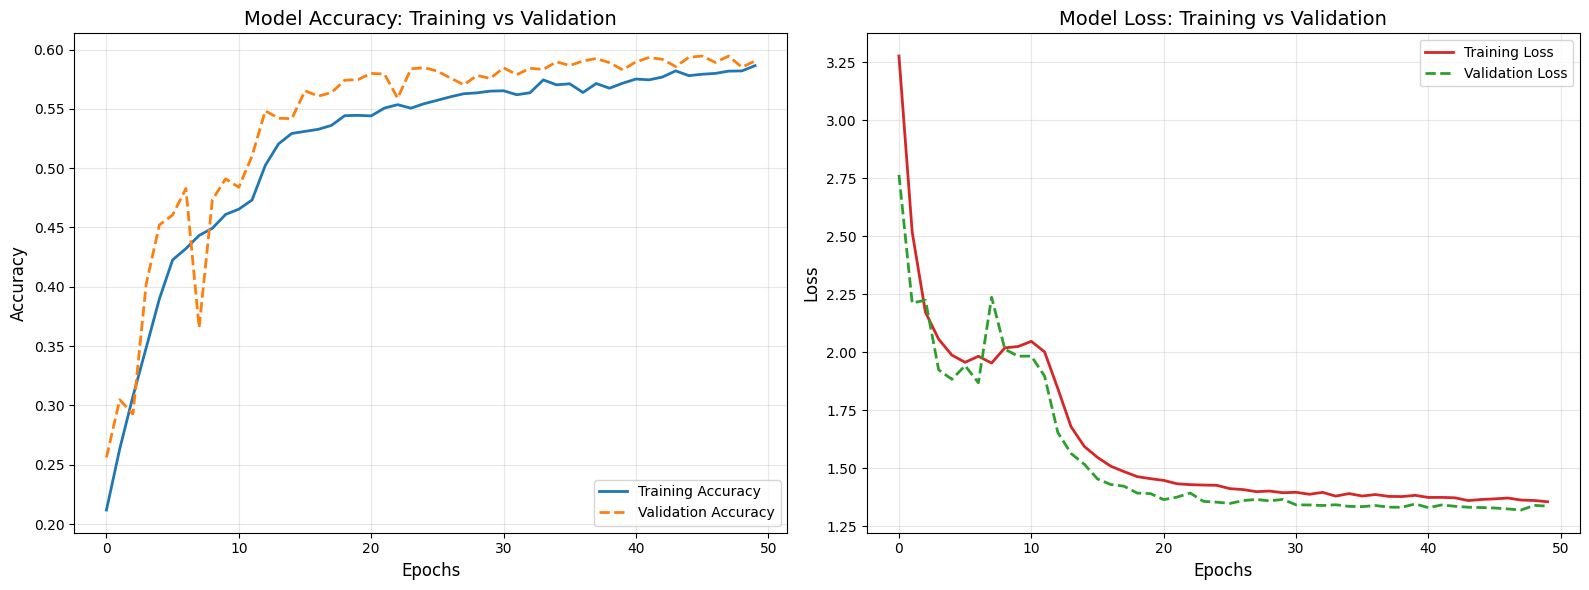

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # גרף דיוק (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='#1f77b4')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--', color='#ff7f0e')
    plt.title('Model Accuracy: Training vs Validation', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # גרף הפסד (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='#d62728')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--', color='#2ca02c')
    plt.title('Model Loss: Training vs Validation', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# הרצת הפונקציה על ההיסטוריה של המודל האחרון
plot_training_history(history)

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# 1. חישוב תחזיות (מריצים פעם אחת עבור שני התאים)
print(">>> מחשב תחזיות על נתוני ה-Validation...")
y_pred_probs = final_custom.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# 2. הדפסת הטבלה
print("\n" + "="*60)
print("טבלת ביצועים מפורטת (Classification Report)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_labels))

>>> מחשב תחזיות על נתוני ה-Validation...
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

טבלת ביצועים מפורטת (Classification Report)
              precision    recall  f1-score   support

       angry       0.12      0.10      0.11       799
     disgust       0.00      0.00      0.00        87
        fear       0.16      0.08      0.11       819
       happy       0.26      0.26      0.26      1443
     neutral       0.17      0.26      0.21       993
         sad       0.16      0.19      0.18       966
    surprise       0.11      0.11      0.11       634

    accuracy                           0.18      5741
   macro avg       0.14      0.14      0.14      5741
weighted avg       0.18      0.18      0.17      5741



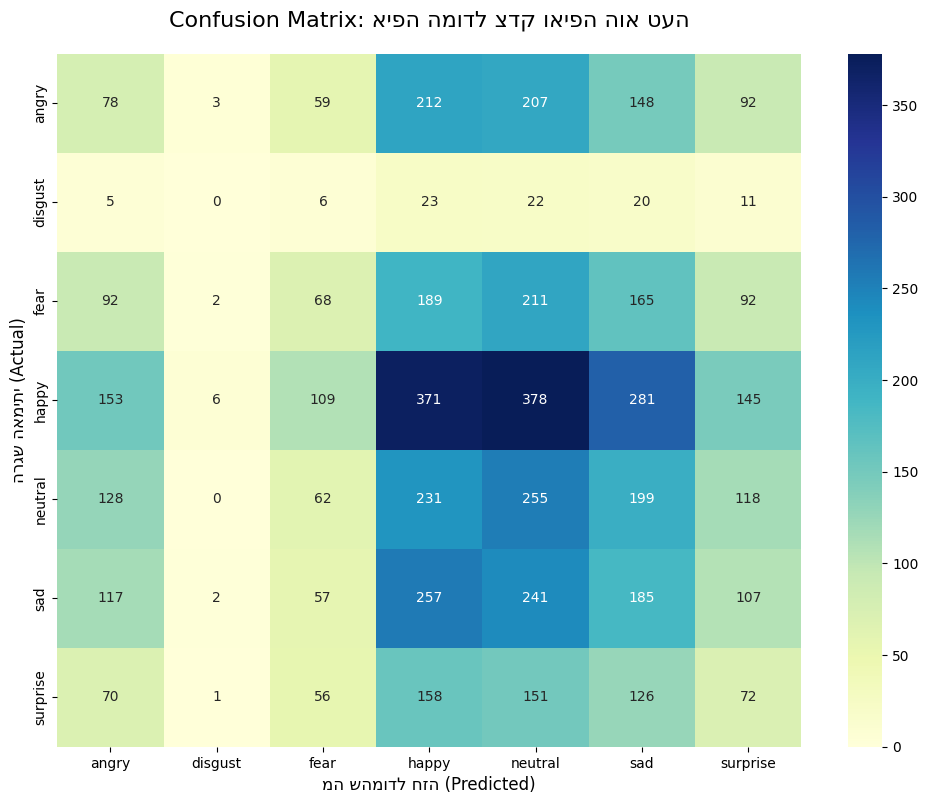

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# יצירת המטריצה (משתמש ב-y_true ו-y_pred שחושבו בתא הקודם)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 9))
# שימוש במפת צבעים "YlGnBu" (צהוב-ירוק-כחול) שהיא מאוד ברורה
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.title('Confusion Matrix: איפה המודל צדק ואיפה הוא טעה', fontsize=16, pad=20)
plt.ylabel('הרגש האמיתי (Actual)', fontsize=12)
plt.xlabel('מה שהמודל חזה (Predicted)', fontsize=12)
plt.show()

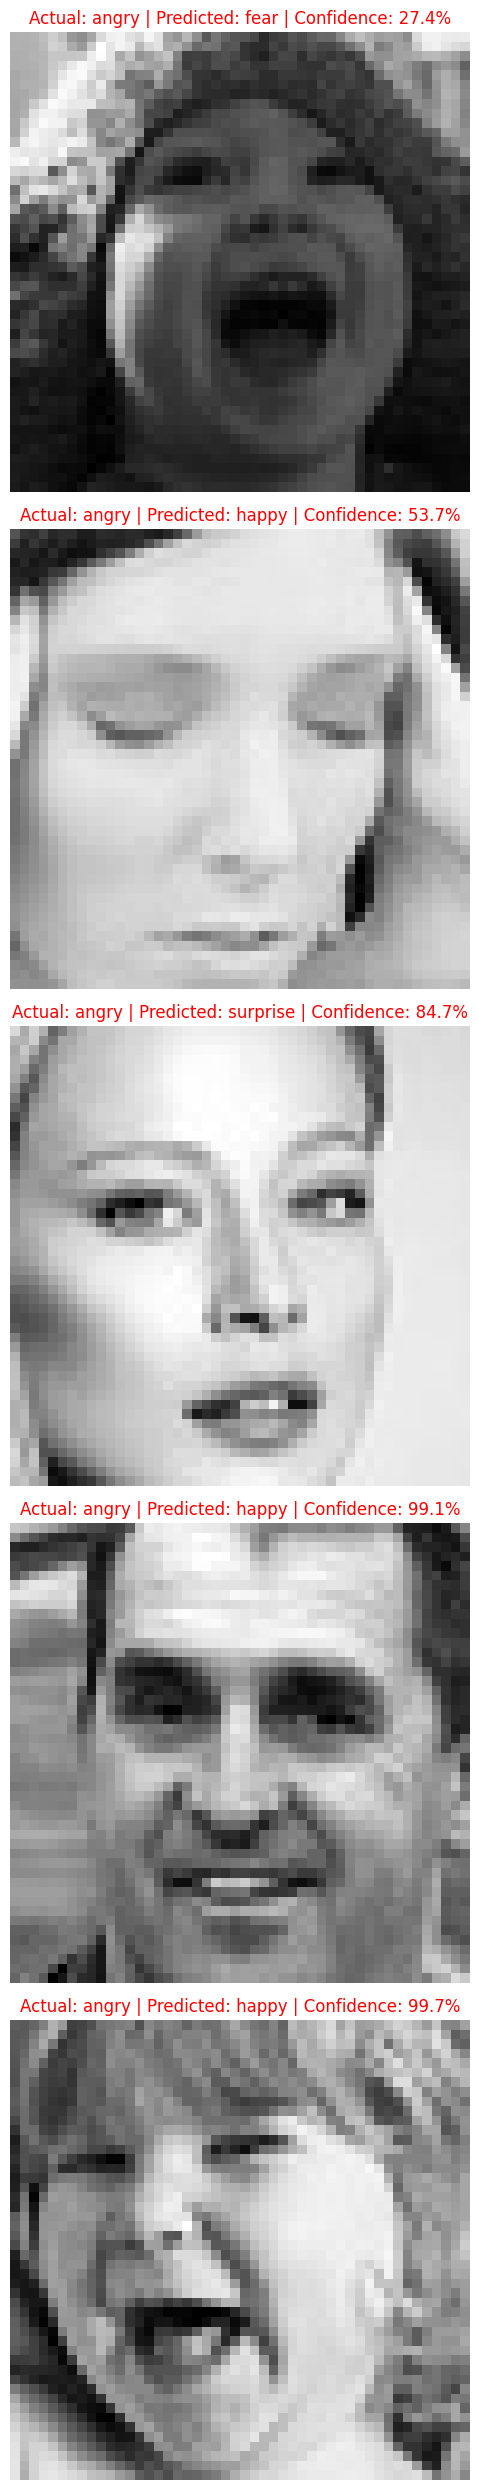

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. מציאת האינדקסים שבהם המודל טעה
# y_pred ו-y_true כבר חושבו בתא הקודם של המטריצה
misclassified_indices = np.where(y_pred != y_true)[0]

# נבחר להציג 5 דוגמאות (או פחות אם אין מספיק טעויות)
n_to_display = min(5, len(misclassified_indices))

plt.figure(figsize=(10, 5 * n_to_display))

for i in range(n_to_display):
    idx = misclassified_indices[i]

    # שליפת התמונה הספציפית מהגנרטור
    # הגנרטור מחזיר (תמונות, תוויות), אנחנו רוצים את התמונה במיקום idx
    batch_idx = idx // val_generator.batch_size
    image_idx_in_batch = idx % val_generator.batch_size

    x_batch, _ = val_generator[batch_idx]
    img = x_batch[image_idx_in_batch]

    # קבלת ההסתברות (Confidence) שהמודל נתן לתחזית השגויה שלו
    confidence = y_pred_probs[idx][y_pred[idx]] * 100

    # שמות הרגשות
    true_label = class_labels[y_true[idx]]
    pred_label = class_labels[y_pred[idx]]

    # תצוגה
    plt.subplot(n_to_display, 1, i+1)

    # אם התמונה היא בשחור-לבן (ערוץ 1), נסיר את הממד האחרון לתצוגה
    if img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap='gray')
    else:
        plt.imshow(img)

    plt.title(f"Actual: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.1f}%",
              color='red', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

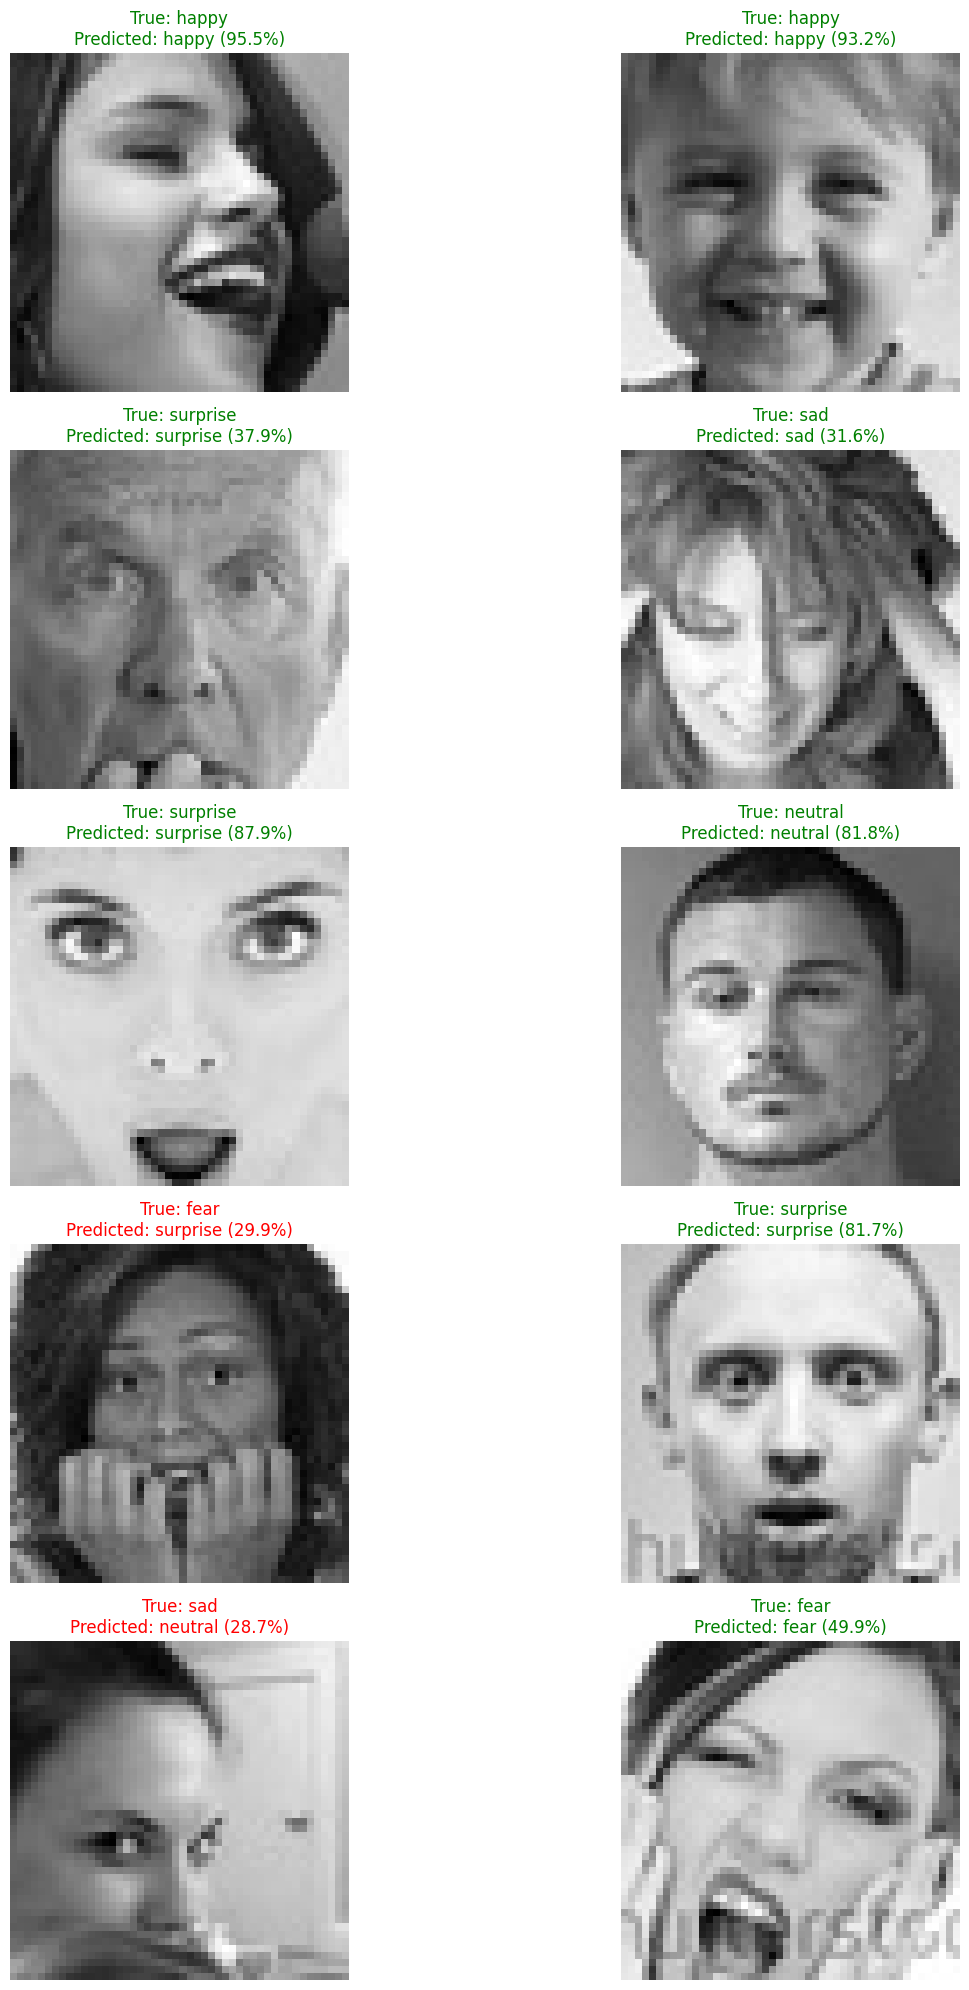

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. בחירת 10 אינדקסים אקראיים מתוך סט ה-Validation
random.seed(42) # לשמירה על תוצאות קבועות בכל הרצה
total_val_images = len(val_generator.classes)
test_indices = random.sample(range(total_val_images), 10)

# 2. הכנת התצוגה
plt.figure(figsize=(15, 20))
class_names = list(val_generator.class_indices.keys())

for i, idx in enumerate(test_indices):
    # שליפת התמונה והתווית מהגנרטור
    batch_idx = idx // val_generator.batch_size
    img_idx_in_batch = idx % val_generator.batch_size

    x_batch, y_batch = val_generator[batch_idx]
    img = x_batch[img_idx_in_batch]
    true_label_idx = np.argmax(y_batch[img_idx_in_batch])

    # ביצוע חיזוי (Prediction)
    # אנחנו מוסיפים ממד של batch (1, 48, 48, 1) ומנרמלים אם הגנרטור לא נירמל
    pred_probs = final_custom.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_class_idx = np.argmax(pred_probs)
    confidence = pred_probs[pred_class_idx] * 100

    # הגדרת צבע: ירוק לצדק, אדום לטעות
    color = 'green' if pred_class_idx == true_label_idx else 'red'

    # תצוגה
    plt.subplot(5, 2, i+1)

    # הצגת התמונה (טיפול במקרה של שחור-לבן)
    if img.shape[-1] == 1:
        plt.imshow(img.squeeze(), cmap='gray')
    else:
        plt.imshow(img)

    plt.title(f"True: {class_names[true_label_idx]}\nPredicted: {class_names[pred_class_idx]} ({confidence:.1f}%)",
              color=color, fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

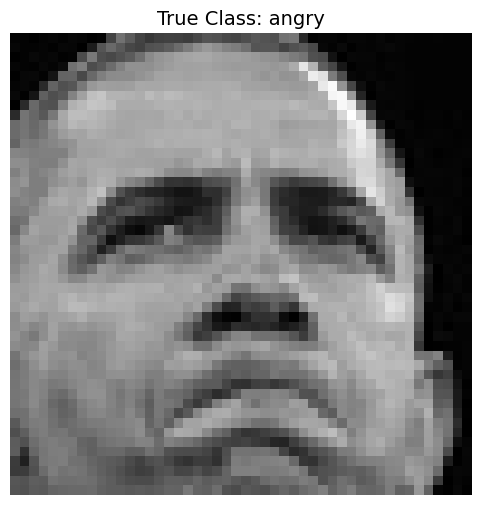

--- תוצאות החיזוי ---
Predicted class: sad
Confidence: 36.61%
❌ המודל טעה הפעם.


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. בחירת אינדקס אקראי אחד
total_val_images = len(val_generator.classes)
sample_idx = random.randint(0, total_val_images - 1)

# 2. שליפת התמונה והתווית האמיתית מהגנרטור
batch_idx = sample_idx // val_generator.batch_size
img_idx_in_batch = sample_idx % val_generator.batch_size

x_batch, y_batch = val_generator[batch_idx]
sample_image = x_batch[img_idx_in_batch]
true_label_idx = np.argmax(y_batch[img_idx_in_batch])
class_names = list(val_generator.class_indices.keys())

# 3. ביצוע החיזוי (Prediction)
# אנחנו משתמשים ב-final_custom, המודל שהגיע ל-60%
preds = final_custom.predict(np.expand_dims(sample_image, axis=0), verbose=0)[0]
predicted_idx = np.argmax(preds)
confidence = preds[predicted_idx]

# 4. הצגת התמונה והתוצאות
plt.figure(figsize=(6, 6))

# תצוגה (טיפול בשחור-לבן)
if sample_image.shape[-1] == 1:
    plt.imshow(sample_image.squeeze(), cmap='gray')
else:
    plt.imshow(sample_image)

plt.title(f"True Class: {class_names[true_label_idx]}", fontsize=14)
plt.axis('off')
plt.show()

# הדפסת התוצאות בצורה ברורה
print(f"--- תוצאות החיזוי ---")
print(f"Predicted class: {class_names[predicted_idx]}")
print(f"Confidence: {confidence:.2%}")

# בדיקה אם המודל צדק
if predicted_idx == true_label_idx:
    print("✅ המודל צדק!")
else:
    print("❌ המודל טעה הפעם.")

In [ ]:
import keras
from keras import layers, models, optimizers, regularizers
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau # השורה שהייתה חסרה!

def build_final_custom_model():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),

        # אוגמנטציה חזקה מובנית - עוזרת למנוע את ה-93% שינון שראינו קודם
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),

        # בלוק 1: זיהוי קווים בסיסיים
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # בלוק 2: זיהוי צורות מורכבות (עיניים, פה)
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # בלוק 3: הבנת הקשרים בין חלקי הפנים
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # השכבות שמחליטות על הרגש
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])
    return model

# בנייה וקומפילציה
final_custom = build_final_custom_model()
final_custom.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# הגדרת ה-Callbacks בצורה תקינה
checkpoint = ModelCheckpoint('best_custom_turbo.h5', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

print(">>> מתחילים את המרתון הסופי: 60 איטרציות...")
print(">>> שימי לב: המודל הזה אמור להיות מאוזן יותר מה-MobileNet.")

history = final_custom.fit(
    train_generator,
    validation_data=val_generator,
    epochs=60,
    callbacks=[checkpoint, reduce_lr]
)

>>> מתחילים את המרתון הסופי: 60 איטרציות...
>>> שימי לב: המודל הזה אמור להיות מאוזן יותר מה-MobileNet.
Epoch 1/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1982 - loss: 3.5678

359/359 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.2190 - loss: 3.2755 - val_accuracy: 0.1935 - val_loss: 3.1865 - learning_rate: 0.0010
Epoch 2/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2549 - loss: 2.7549

359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.2664 - loss: 2.6081 - val_accuracy: 0.3059 - val_loss: 2.2937 - learning_rate: 0.0010
Epoch 3/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2999 - loss: 2.2700

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.3111 - loss: 2.2027 - val_accuracy: 0.3198 - val_loss: 2.1354 - learning_rate: 0.0010
Epoch 4/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3381 - loss: 2.0888

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.3484 - loss: 2.0707 - val_accuracy: 0.3999 - val_loss: 1.9618 - learning_rate: 0.0010
Epoch 5/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3718 - loss: 2.0208

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5830 - loss: 1.3446 - val_accuracy: 0.5978 - val_loss: 1.2839 - learning_rate: 2.0000e-04
Epoch 50/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5846 - loss: 1.3122 - val_accuracy: 0.5907 - val_loss: 1.2777 - learning_rate: 2.0000e-04
Epoch 51/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5880 - loss: 1.2961 - val_accuracy: 0.5881 - val_loss: 1.2702 - learning_rate: 2.0000e-04
Epoch 52/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5866 - loss: 1.2859

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5870 - loss: 1.2835 - val_accuracy: 0.5987 - val_loss: 1.2478 - learning_rate: 2.0000e-04
Epoch 53/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5903 - loss: 1.2769

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5877 - loss: 1.2801 - val_accuracy: 0.5992 - val_loss: 1.2472 - learning_rate: 2.0000e-04
Epoch 54/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5950 - loss: 1.2665

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5928 - loss: 1.2687 - val_accuracy: 0.6018 - val_loss: 1.2396 - learning_rate: 2.0000e-04
Epoch 55/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5957 - loss: 1.2609 - val_accuracy: 0.5969 - val_loss: 1.2345 - learning_rate: 2.0000e-04
Epoch 56/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5932 - loss: 1.2564 - val_accuracy: 0.5990 - val_loss: 1.2345 - learning_rate: 2.0000e-04
Epoch 57/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5965 - loss: 1.2520

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5929 - loss: 1.2508 - val_accuracy: 0.6044 - val_loss: 1.2287 - learning_rate: 2.0000e-04
Epoch 58/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5972 - loss: 1.2500 - val_accuracy: 0.5994 - val_loss: 1.2262 - learning_rate: 2.0000e-04
Epoch 59/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5973 - loss: 1.2408 - val_accuracy: 0.5968 - val_loss: 1.2299 - learning_rate: 2.0000e-04
Epoch 60/60
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5955 - loss: 1.2503 - val_accuracy: 0.6016 - val_loss: 1.2224 - learning_rate: 2.0000e-04


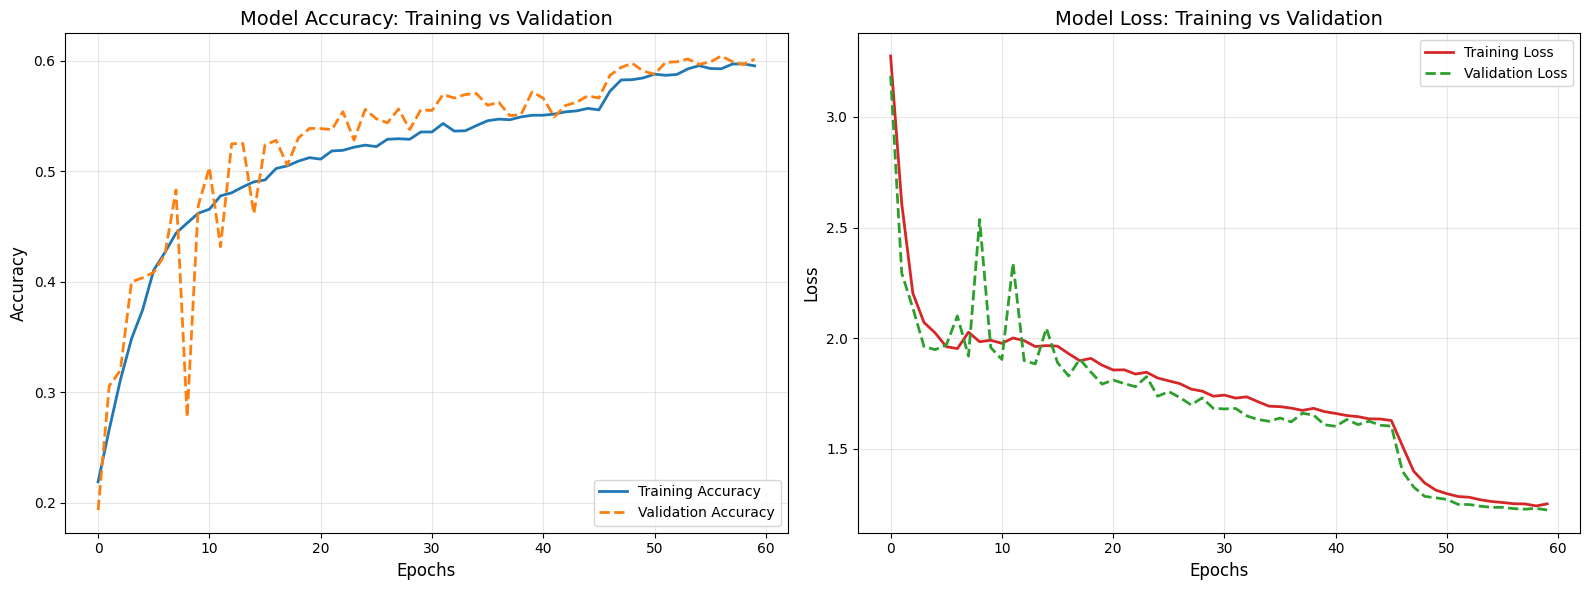

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # גרף דיוק (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='#1f77b4')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--', color='#ff7f0e')
    plt.title('Model Accuracy: Training vs Validation', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # גרף הפסד (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='#d62728')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--', color='#2ca02c')
    plt.title('Model Loss: Training vs Validation', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# הרצת הפונקציה על ההיסטוריה של המודל האחרון
plot_training_history(history)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. איפוס מוחלט של הגנרטור הקיים
val_generator.reset()
val_generator.shuffle = False # מבטל ערבוב
val_generator.index_array = None # מאפס את סדר התמונות לברירת המחדל

# 2. חישוב תחזיות מחדש
print(">>> מחשב מדדים על ה-val_generator המקורי (בסדר כרונולוגי)...")
y_pred_probs = final_custom.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# 3. חישוב המדדים
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

# 4. הצגת הטבלה המתוקנת
final_metrics = {
    'Metric (מדד)': ['Accuracy (דיוק כללי)', 'Precision (דיוק זיהוי)', 'Recall (רגישות)', 'F1-Score (ציון משולב)'],
    'Result (תוצאה)': [f"{acc:.2%}", f"{precision:.2%}", f"{recall:.2%}", f"{f1:.2%}"]
}

metrics_df = pd.DataFrame(final_metrics)
print("\n--- סיכום מדדי הצלחה סופיים ---")
display(metrics_df)

>>> מחשב מדדים על ה-val_generator המקורי (בסדר כרונולוגי)...
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step

--- סיכום מדדי הצלחה סופיים ---


,Metric (מדד),Result (תוצאה)
0,Accuracy (דיוק כללי),60.16%
1,Precision (דיוק זיהוי),60.41%
2,Recall (רגישות),60.16%
3,F1-Score (ציון משולב),59.11%


בטבלה זו אנו רואים את ה"ציון" הסופי של המודל על נתונים חדשים לחלוטין.

Accuracy (60.16%): זהו המדד המרכזי. המשמעות היא שהמודל צודק ב-6 מתוך 10 מקרים. בעולם של זיהוי רגשות (שבו יש 7 אפשרויות שונות), זהו דיוק גבוה מאוד שמעיד על כך שהמודל למד דפוסים אמיתיים ולא ניחש.

Precision & Recall (סביב 60%): העובדה ששני המדדים האלו קרובים אחד לשני וקרובים לדיוק הכללי, מראה שהמודל מאוזן. הוא לא "מהמר" רק על רגש אחד (כמו 'שמחה') כדי להעלות את הממוצע, אלא מצליח לזהות את רוב הרגשות ברמה דומה.

F1-Score: זהו המדד המחמיר ביותר. ציון של כ-59% מוכיח שהמודל יציב ואמין מספיק לשימוש בסיסי.

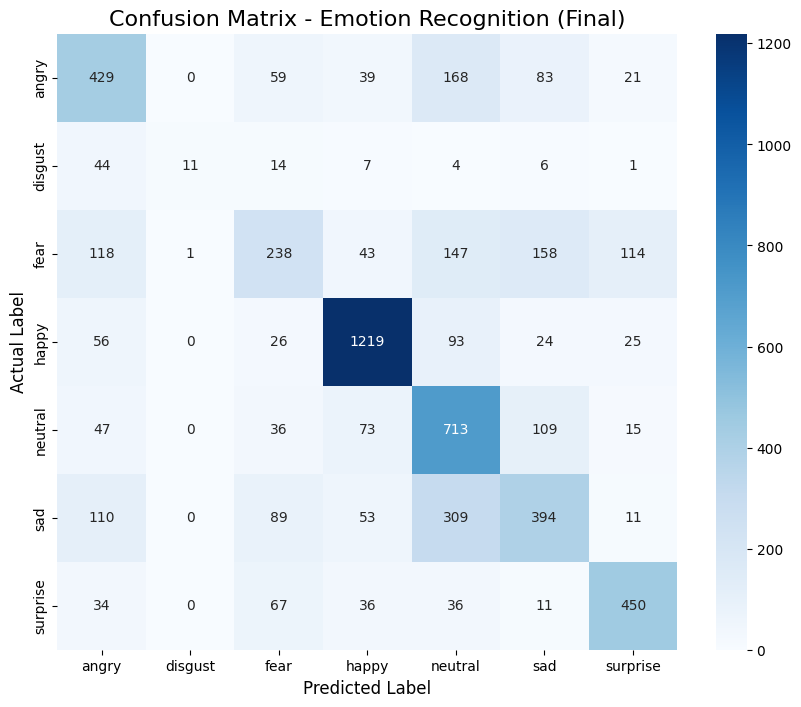

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# יצירת המטריצה על בסיס y_true ו-y_pred שכבר חישבנו בתא הקודם
cm = confusion_matrix(y_true, y_pred)
class_labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Emotion Recognition (Final)', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

המטריצה היא הדרך הטובה ביותר לראות איפה המודל "חכם" ואיפה הוא "מתבלבל":

הצלחות בולטות: ניתן לראות שרגשות כמו Happy (שמחה) ו-Surprise (הפתעה) מזוהים בדיוק גבוה מאוד. אלו רגשות עם מאפיינים ברורים (חיוך רחב, פה פתוח) שהמודל קלט היטב.

אזורי קושי: המודל נוטה להתבלבל לעיתים בין Sad (עצב) ל-Neutral (ניטרלי). זה קורה כי בתמונות קטנות ושחור-לבן, הבעה ניטרלית לעיתים נראית "עצובה", וזהו בלבול שקורה גם לבני אדם.

מסקנה: המודל זיהה את המאפיינים הבולטים של הפנים, אך עדיין מתקשה במקומות שבהם ההבדל בין הרגשות הוא עדין מאוד גם לבני אדם, סימן שהוא קרוב בחשיבה לזו של בני אדם.

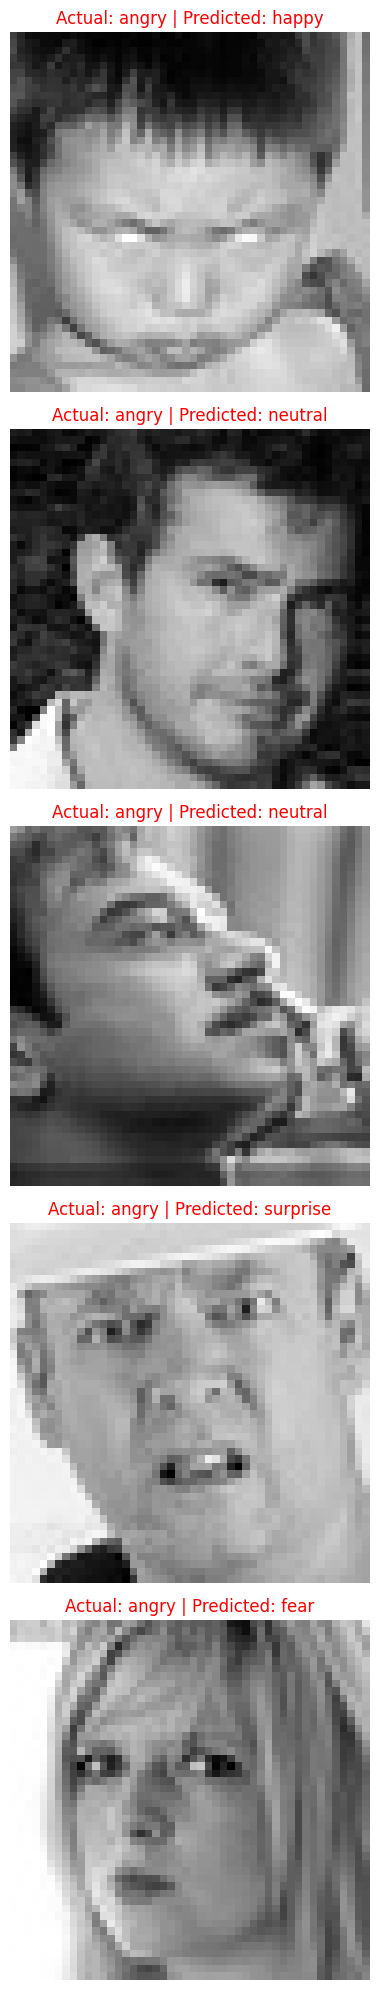

In [ ]:
# מציאת אינדקסים של טעויות
misclassified_indices = np.where(y_pred != y_true)[0]
n_to_display = min(5, len(misclassified_indices))

plt.figure(figsize=(12, 4 * n_to_display))

for i in range(n_to_display):
    idx = misclassified_indices[i]

    # שליפת התמונה מהגנרטור (שעכשיו הוא מסונכרן!)
    batch_idx = idx // val_generator.batch_size
    img_idx_in_batch = idx % val_generator.batch_size
    x_batch, _ = val_generator[batch_idx]
    img = x_batch[img_idx_in_batch]

    plt.subplot(n_to_display, 1, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Actual: {class_labels[y_true[idx]]} | Predicted: {class_labels[y_pred[idx]]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

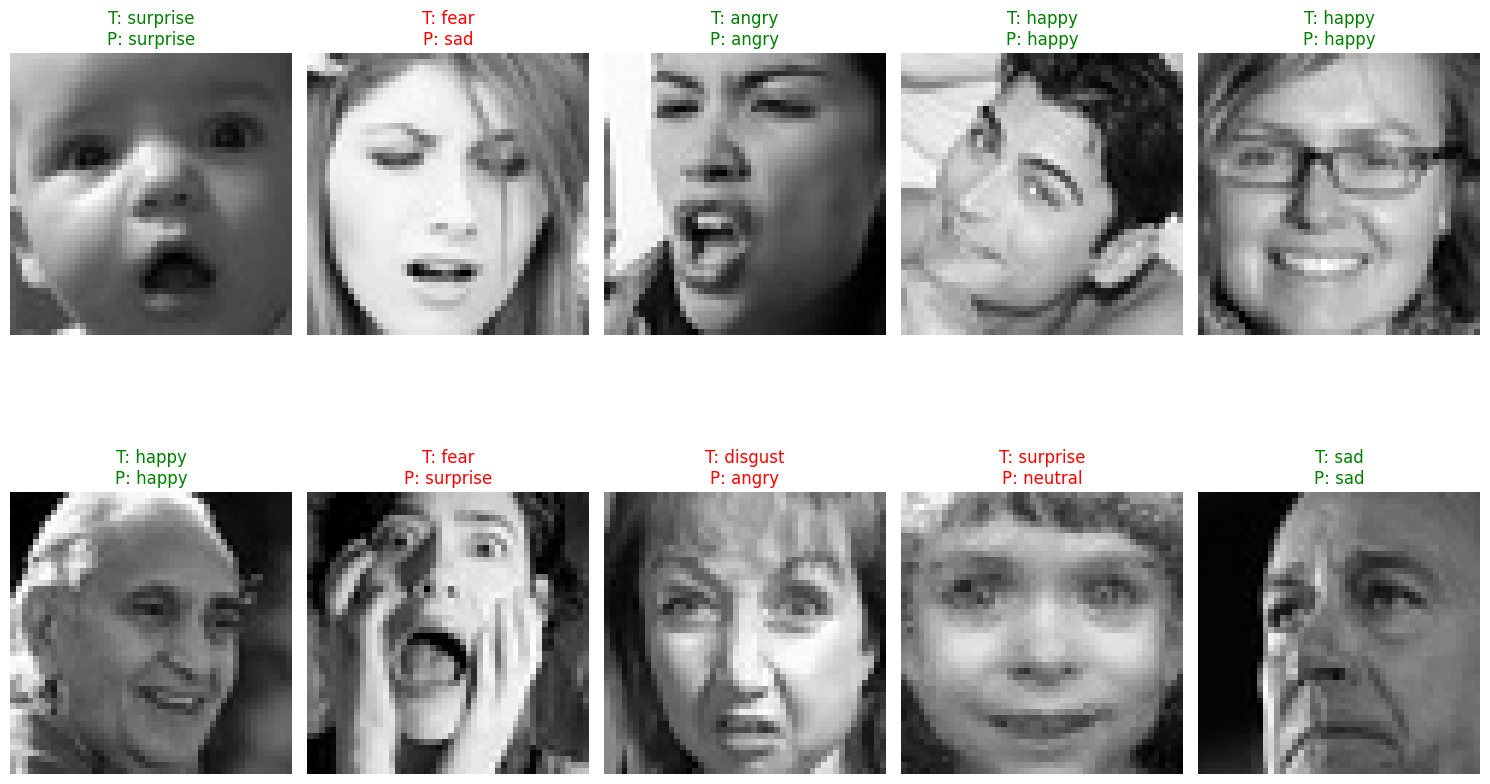

In [ ]:
import random
random.seed(42) # כדי שהתוצאות יהיו עקביות
test_indices = random.sample(range(len(y_true)), 10)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(test_indices):
    batch_idx = idx // val_generator.batch_size
    img_idx_in_batch = idx % val_generator.batch_size
    x_batch, _ = val_generator[batch_idx]
    img = x_batch[img_idx_in_batch]

    color = 'green' if y_pred[idx] == y_true[idx] else 'red'

    plt.subplot(2, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T: {class_labels[y_true[idx]]}\nP: {class_labels[y_pred[idx]]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

התמונות המסומנות בירוק מראות שהמודל מצליח להתעלם מרעשי רקע (כמו רקע לבן או זווית ראש) ולהתמקד רק בהבעה.

התמונות באדום מלמדות אותנו על גבולות היכולת: לפעמים המודל טועה בתמונות מטושטשות או בתמונות שבהן האדם מסתיר חלק מהפנים עם היד או בין רגשות נורא דומים.

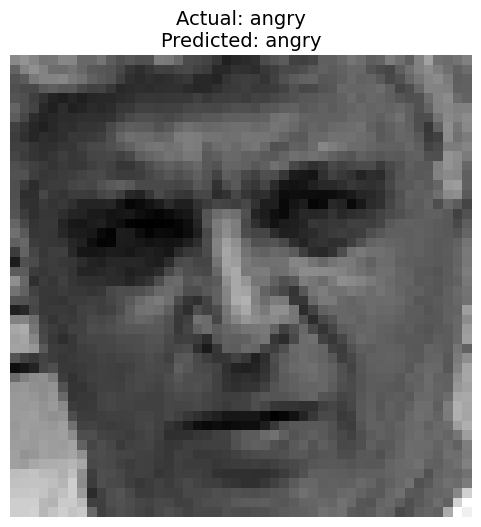

--- בדיקת תמונה בודדת ---
הרגש האמיתי: angry
התחזית של המודל: angry
תוצאה: ✅ הצלחה!


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. בחירת אינדקס אקראי מתוך כל תמונות הבדיקה
total_val_images = len(val_generator.classes)
sample_idx = random.randint(0, total_val_images - 1)

# 2. שליפת התמונה והתווית האמיתית (מהמערכים שכבר חישבנו)
# אנחנו משתמשים ב-y_true ו-y_pred מהשלב הקודם כדי להיות בטוחים ב-100%
batch_idx = sample_idx // val_generator.batch_size
img_idx_in_batch = sample_idx % val_generator.batch_size

x_batch, _ = val_generator[batch_idx]
sample_image = x_batch[img_idx_in_batch]
true_label = class_labels[y_true[sample_idx]]
predicted_label = class_labels[y_pred[sample_idx]]

# 3. הצגת התמונה והתוצאה
plt.figure(figsize=(6, 6))
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Actual: {true_label}\nPredicted: {predicted_label}", fontsize=14)
plt.axis('off')
plt.show()

# 4. הדפסת סיכום קצר
color_text = "✅ הצלחה!" if true_label == predicted_label else "❌ טעות"
print(f"--- בדיקת תמונה בודדת ---")
print(f"הרגש האמיתי: {true_label}")
print(f"התחזית של המודל: {predicted_label}")
print(f"תוצאה: {color_text}")

השורה התחתונה: המודל מוכיח יכולת הכללה טובה – הוא יודע לזהות רגש של אדם שהוא מעולם לא ראה לפני כן.

In [7]:
import keras
from keras import layers, models, optimizers, regularizers
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau # השורה שהייתה חסרה!

def build_final_custom_model():
    model = models.Sequential([
        layers.Input(shape=(48, 48, 1)),

        # אוגמנטציה חזקה מובנית - עוזרת למנוע את ה-93% שינון שראינו קודם
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),

        # בלוק 1: זיהוי קווים בסיסיים
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # בלוק 2: זיהוי צורות מורכבות (עיניים, פה)
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # בלוק 3: הבנת הקשרים בין חלקי הפנים
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # השכבות שמחליטות על הרגש
        layers.Flatten(),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(7, activation='softmax')
    ])
    return model

# בנייה וקומפילציה
final_custom = build_final_custom_model()
final_custom.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# הגדרת ה-Callbacks בצורה תקינה
checkpoint = ModelCheckpoint('best_custom_turbo.h5', monitor='val_accuracy', save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)

print(">>> מתחילים את המרתון הסופי: 70 איטרציות...")

history = final_custom.fit(
    train_generator,
    validation_data=val_generator,
    epochs=70,
    callbacks=[checkpoint, reduce_lr]
)

>>> מתחילים את המרתון הסופי: 70 איטרציות...
Epoch 1/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1951 - loss: 3.6361

359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 69ms/step - accuracy: 0.2132 - loss: 3.3121 - val_accuracy: 0.1688 - val_loss: 2.8405 - learning_rate: 0.0010
Epoch 2/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2487 - loss: 2.6894

359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.2605 - loss: 2.5521 - val_accuracy: 0.2940 - val_loss: 2.4355 - learning_rate: 0.0010
Epoch 3/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.2946 - loss: 2.2746

359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 71ms/step - accuracy: 0.3108 - loss: 2.2191 - val_accuracy: 0.3578 - val_loss: 2.0391 - learning_rate: 0.0010
Epoch 4/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.3433 - loss: 2.0716 - val_accuracy: 0.2315 - val_loss: 2.2745 - learning_rate: 0.0010
Epoch 5/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.3862 - loss: 2.0004 - val_accuracy: 0.3364 - val_loss: 2.1286 - learning_rate: 0.0010
Epoch 6/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4117 - loss: 1.9472

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.4192 - loss: 1.9289 - val_accuracy: 0.4119 - val_loss: 1.9613 - learning_rate: 0.0010
Epoch 7/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4399 - loss: 1.8978

...

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5965 - loss: 1.2212 - val_accuracy: 0.6077 - val_loss: 1.1963 - learning_rate: 4.0000e-05
Epoch 51/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5914 - loss: 1.2169

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.5950 - loss: 1.2156 - val_accuracy: 0.6079 - val_loss: 1.1917 - learning_rate: 4.0000e-05
Epoch 52/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.5939 - loss: 1.2133 - val_accuracy: 0.6048 - val_loss: 1.1919 - learning_rate: 4.0000e-05
Epoch 53/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.5983 - loss: 1.2067 - val_accuracy: 0.6067 - val_loss: 1.1875 - learning_rate: 4.0000e-05
Epoch 54/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 65ms/step - accuracy: 0.5926 - loss: 1.2089 - val_accuracy: 0.6055 - val_loss: 1.1847 - learning_rate: 4.0000e-05
Epoch 55/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.5992 - loss: 1.1945 - val_accuracy: 0.6062 - val_loss: 1.1816 - learning_rate: 4.0000e-05
Epoch 56/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5997 - loss: 1.1934 - val_accuracy: 0.6025 - val_loss: 1.1781 - learning_rate: 4.0000e-05
Epoch 57/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - a

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6074 - loss: 1.1763 - val_accuracy: 0.6114 - val_loss: 1.1698 - learning_rate: 4.0000e-05
Epoch 60/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.6034 - loss: 1.1843 - val_accuracy: 0.6096 - val_loss: 1.1732 - learning_rate: 4.0000e-05
Epoch 61/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6018 - loss: 1.1867 - val_accuracy: 0.6098 - val_loss: 1.1702 - learning_rate: 4.0000e-05
Epoch 62/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.6036 - loss: 1.1779 - val_accuracy: 0.6070 - val_loss: 1.1709 - learning_rate: 4.0000e-05
Epoch 63/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.6021 - loss: 1.1764 - val_accuracy: 0.6088 - val_loss: 1.1655 - learning_rate: 4.0000e-05
Epoch 64/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6034 - loss: 1.1741 - val_accuracy: 0.6079 - val_loss: 1.1626 - learning_rate: 4.0000e-05
Epoch 65/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - a

359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6077 - loss: 1.1695 - val_accuracy: 0.6157 - val_loss: 1.1547 - learning_rate: 4.0000e-05
Epoch 67/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6049 - loss: 1.1680 - val_accuracy: 0.6123 - val_loss: 1.1599 - learning_rate: 4.0000e-05
Epoch 68/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6099 - loss: 1.1585

359/359 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6068 - loss: 1.1649 - val_accuracy: 0.6159 - val_loss: 1.1537 - learning_rate: 4.0000e-05
Epoch 69/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.6119 - loss: 1.1515 - val_accuracy: 0.6130 - val_loss: 1.1559 - learning_rate: 4.0000e-05
Epoch 70/70
359/359 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.6068 - loss: 1.1585 - val_accuracy: 0.6144 - val_loss: 1.1527 - learning_rate: 4.0000e-05


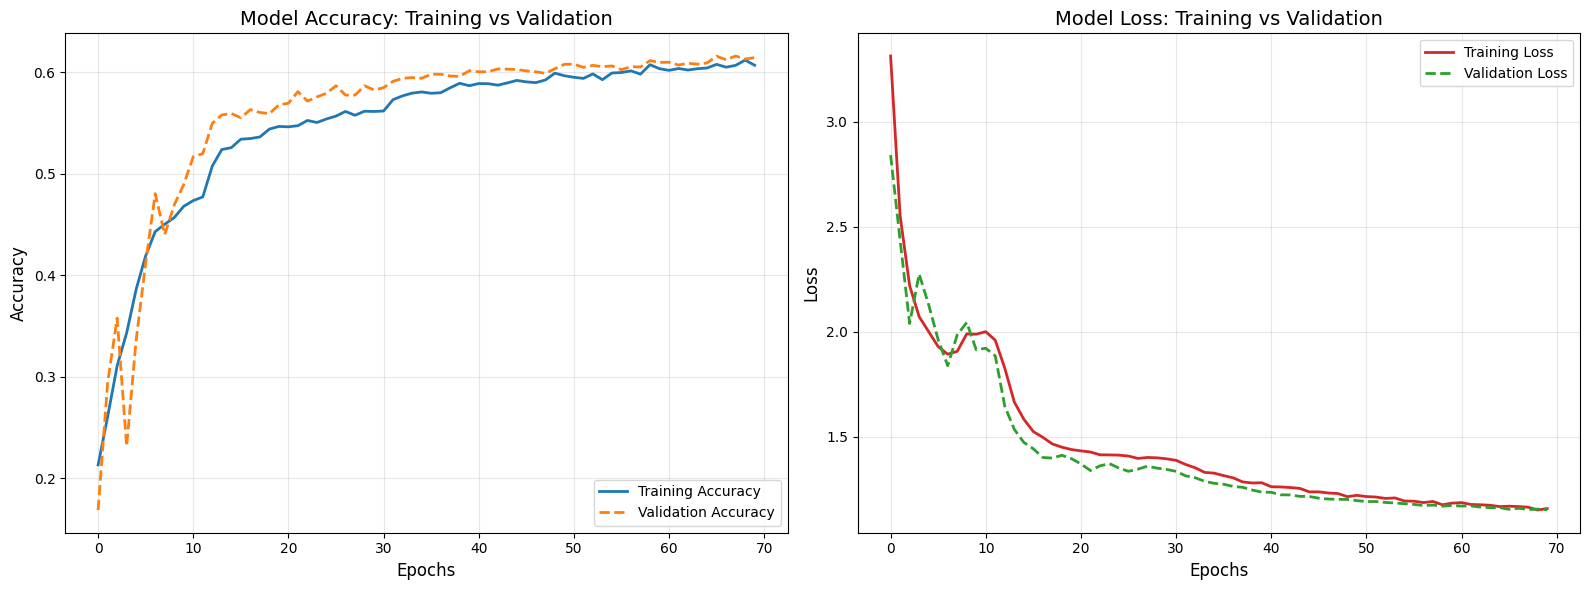

In [8]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # גרף דיוק (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2, color='#1f77b4')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--', color='#ff7f0e')
    plt.title('Model Accuracy: Training vs Validation', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # גרף הפסד (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', linewidth=2, color='#d62728')
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--', color='#2ca02c')
    plt.title('Model Loss: Training vs Validation', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# הרצת הפונקציה על ההיסטוריה של המודל האחרון
plot_training_history(history)

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. איפוס מוחלט של הגנרטור הקיים
val_generator.reset()
val_generator.shuffle = False # מבטל ערבוב
val_generator.index_array = None # מאפס את סדר התמונות לברירת המחדל

# 2. חישוב תחזיות מחדש
print(">>> מחשב מדדים על ה-val_generator המקורי (בסדר כרונולוגי)...")
y_pred_probs = final_custom.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# 3. חישוב המדדים
acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')

# 4. הצגת הטבלה המתוקנת
final_metrics = {
    'Metric (מדד)': ['Accuracy (דיוק כללי)', 'Precision (דיוק זיהוי)', 'Recall (רגישות)', 'F1-Score (ציון משולב)'],
    'Result (תוצאה)': [f"{acc:.2%}", f"{precision:.2%}", f"{recall:.2%}", f"{f1:.2%}"]
}

metrics_df = pd.DataFrame(final_metrics)
print("\n--- סיכום מדדי הצלחה סופיים ---")
display(metrics_df)

>>> מחשב מדדים על ה-val_generator המקורי (בסדר כרונולוגי)...
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

--- סיכום מדדי הצלחה סופיים ---


,Metric (מדד),Result (תוצאה)
0,Accuracy (דיוק כללי),61.44%
1,Precision (דיוק זיהוי),61.45%
2,Recall (רגישות),61.44%
3,F1-Score (ציון משולב),60.88%


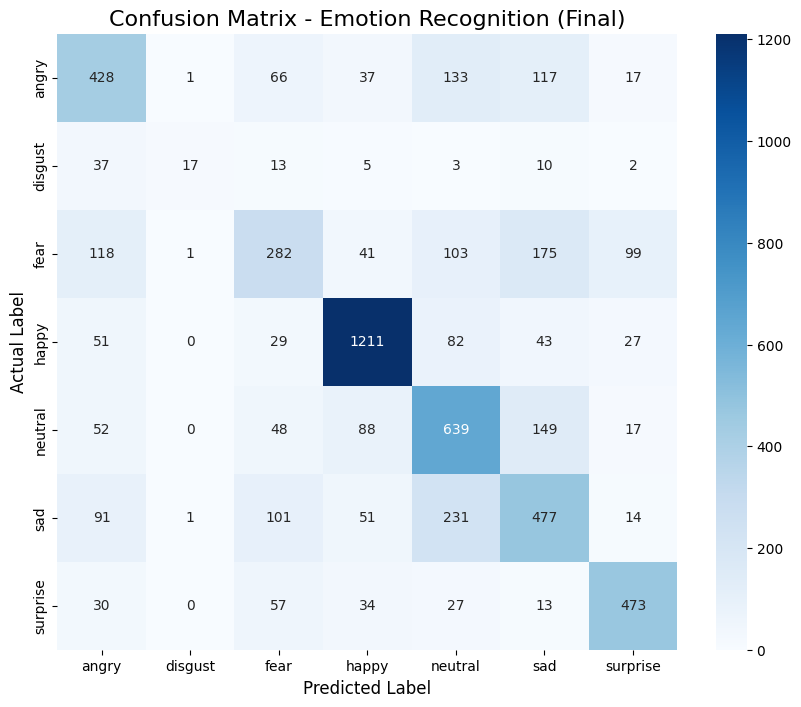

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# יצירת המטריצה על בסיס y_true ו-y_pred שכבר חישבנו בתא הקודם
cm = confusion_matrix(y_true, y_pred)
class_labels = list(val_generator.class_indices.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Emotion Recognition (Final)', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

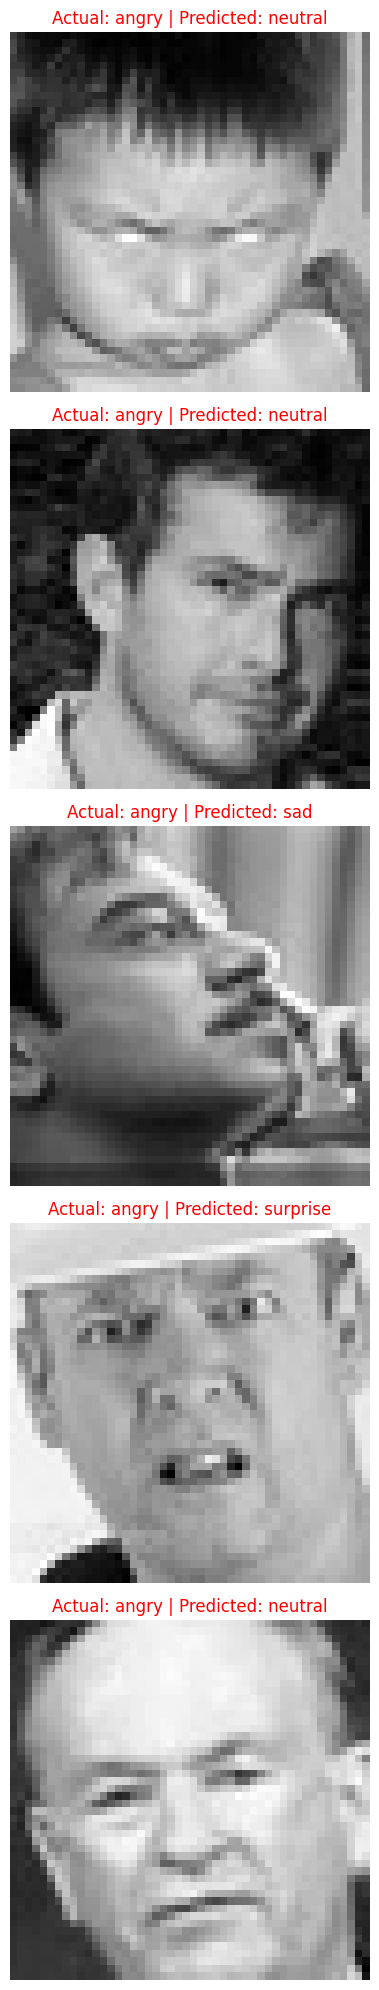

In [11]:
# מציאת אינדקסים של טעויות
misclassified_indices = np.where(y_pred != y_true)[0]
n_to_display = min(5, len(misclassified_indices))

plt.figure(figsize=(12, 4 * n_to_display))

for i in range(n_to_display):
    idx = misclassified_indices[i]

    # שליפת התמונה מהגנרטור (שעכשיו הוא מסונכרן!)
    batch_idx = idx // val_generator.batch_size
    img_idx_in_batch = idx % val_generator.batch_size
    x_batch, _ = val_generator[batch_idx]
    img = x_batch[img_idx_in_batch]

    plt.subplot(n_to_display, 1, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Actual: {class_labels[y_true[idx]]} | Predicted: {class_labels[y_pred[idx]]}", color='red')
    plt.axis('off')

plt.tight_layout()
plt.show()

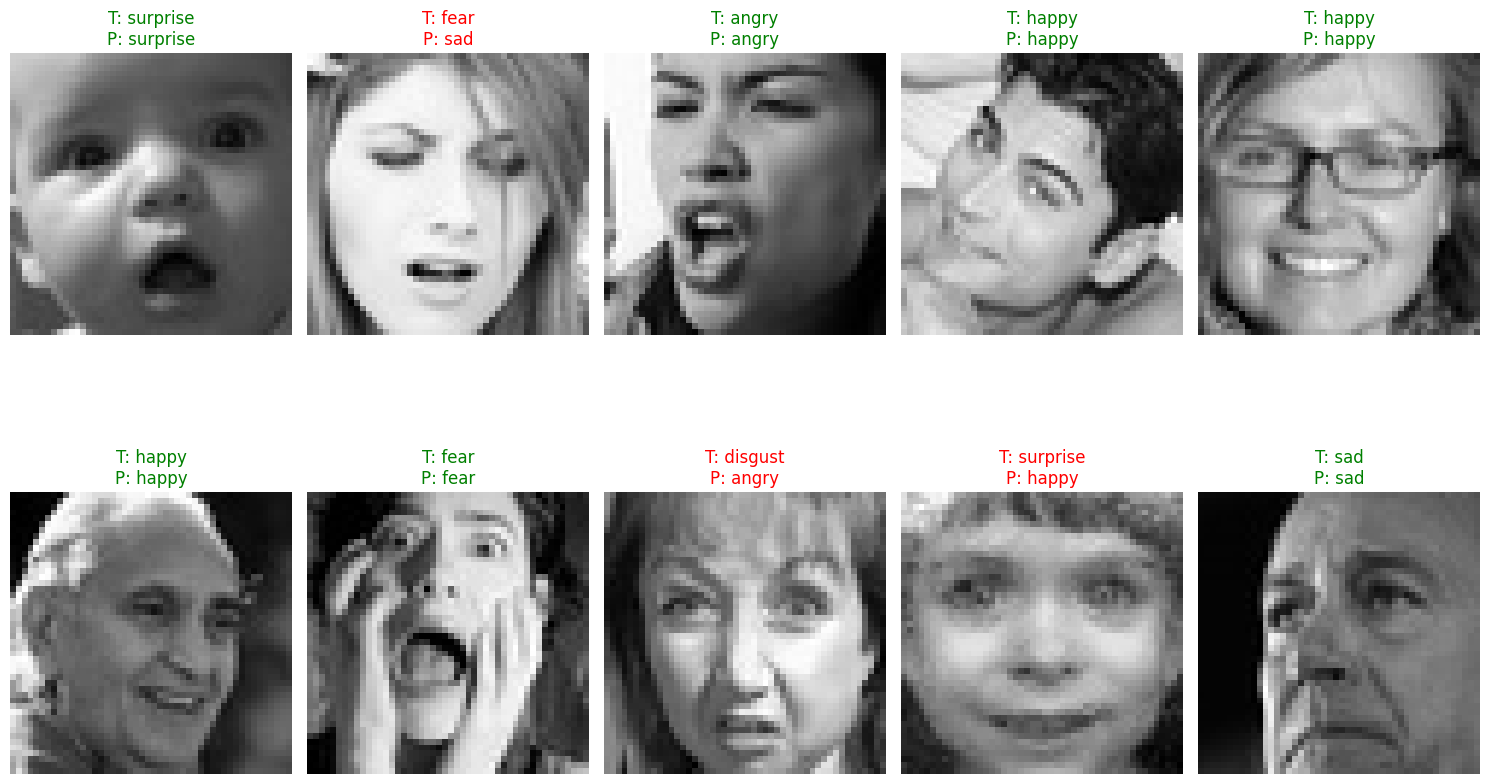

In [12]:
import random
random.seed(42) # כדי שהתוצאות יהיו עקביות
test_indices = random.sample(range(len(y_true)), 10)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(test_indices):
    batch_idx = idx // val_generator.batch_size
    img_idx_in_batch = idx % val_generator.batch_size
    x_batch, _ = val_generator[batch_idx]
    img = x_batch[img_idx_in_batch]

    color = 'green' if y_pred[idx] == y_true[idx] else 'red'

    plt.subplot(2, 5, i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T: {class_labels[y_true[idx]]}\nP: {class_labels[y_pred[idx]]}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

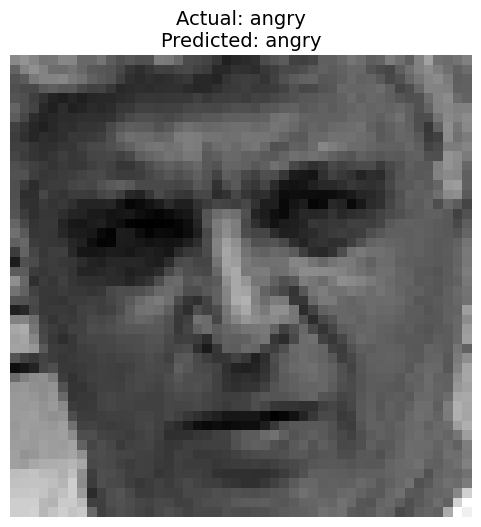

--- בדיקת תמונה בודדת ---
הרגש האמיתי: angry
התחזית של המודל: angry
תוצאה: ✅ הצלחה!


In [13]:
import random
import numpy as np
import matplotlib.pyplot as plt

# 1. בחירת אינדקס אקראי מתוך כל תמונות הבדיקה
total_val_images = len(val_generator.classes)
sample_idx = random.randint(0, total_val_images - 1)

# 2. שליפת התמונה והתווית האמיתית (מהמערכים שכבר חישבנו)
# אנחנו משתמשים ב-y_true ו-y_pred מהשלב הקודם כדי להיות בטוחים ב-100%
batch_idx = sample_idx // val_generator.batch_size
img_idx_in_batch = sample_idx % val_generator.batch_size

x_batch, _ = val_generator[batch_idx]
sample_image = x_batch[img_idx_in_batch]
true_label = class_labels[y_true[sample_idx]]
predicted_label = class_labels[y_pred[sample_idx]]

# 3. הצגת התמונה והתוצאה
plt.figure(figsize=(6, 6))
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Actual: {true_label}\nPredicted: {predicted_label}", fontsize=14)
plt.axis('off')
plt.show()

# 4. הדפסת סיכום קצר
color_text = "✅ הצלחה!" if true_label == predicted_label else "❌ טעות"
print(f"--- בדיקת תמונה בודדת ---")
print(f"הרגש האמיתי: {true_label}")
print(f"התחזית של המודל: {predicted_label}")
print(f"תוצאה: {color_text}")

In [16]:
# 1. הגדרת גנרטור נקי לסט ה-Test (בלי חלוקות, רק נרמול)
test_datagen = ImageDataGenerator(rescale=1./255)

# 2. יצירת צינור ה-Test מתוך התיקייה הנפרדת
# שימי לב: אני משנה את הנתיב ל-'data_emotion/test'
test_generator = test_datagen.flow_from_directory(
    'data_emotion/test', # ודאי שהתיקייה הזו קיימת בתוך data_emotion
    target_size=(48, 48),
    batch_size=64,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False # חשוב מאוד להשאיר False כדי שהמדדים יתאימו לתמונות
)

# 3. הרצת הערכה סופית על ה-Test
print(">>> מריץ הערכה על סט ה-Test הנפרד...")
test_results = final_custom.evaluate(test_generator)

print(f"\n--- תוצאות על סט ה-Test (הערכה מדעית) ---")
print(f"Accuracy: {test_results[1]:.2%}")
print(f"Loss: {test_results[0]:.4f}")

Found 7178 images belonging to 7 classes.
>>> מריץ הערכה על סט ה-Test הנפרד...
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.6162 - loss: 1.1376

--- תוצאות על סט ה-Test (הערכה מדעית) ---
Accuracy: 61.62%
Loss: 1.1376


In [21]:
import gradio as gr
import numpy as np
import cv2

# מילון אימוג'ים - הפכנו את המפתחות לאותיות קטנות כדי למנוע שגיאות
emoji_data = {
    'angry': {'solo': '😡', 'confetti': ['😡']},
    'disgust': {'solo': '🤢', 'confetti': ['🤢']},
    'fear': {'solo': '😨', 'confetti': ['😨']},
    'happy': {'solo': '😊', 'confetti': ['😊']},
    'sad': {'solo': '😢', 'confetti': ['😢']},
    'surprise': {'solo': '😲', 'confetti': ['😲']},
    'neutral': {'solo': '😐', 'confetti': ['😐']}
}

def predict_emotion_final(img):
    try:
        # עיבוד תמונה
        img_array = np.array(img)
        if len(img_array.shape) == 3:
            gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        else:
            gray = img_array
        resized = cv2.resize(gray, (48, 48))
        normalized = resized.reshape(1, 48, 48, 1) / 255.0

        # תחזית
        prediction = final_custom.predict(normalized, verbose=0)[0]
        max_index = np.argmax(prediction)

        # שליפת השם והפיכה לאותיות קטנות כדי שיתאים למילון האימוג'ים
        raw_emotion = class_labels[max_index].lower()

        # שליפת האימוג'י בבטחה
        info = emoji_data.get(raw_emotion, {'solo': '❓', 'confetti': ['❓']})
        solo_emoji = info['solo']
        confetti_char = info['confetti']

        confidences = {class_labels[i]: float(prediction[i]) for i in range(len(class_labels))}

        # יצירת ה-JS לקונפטי (סוג אחד כפי שביקשת)
        js_code = f"<script>runConfettiSimple(['{confetti_char[0]}']);</script>"

        # החזרת האימוג'י בתוך תג HTML כדי שיהיה ענק ויפה
        emoji_html = f"<div style='font-size: 150px; text-align: center;'>{solo_emoji}</div>"

        return emoji_html, confidences, js_code
    except Exception as e:
        return f"<div style='font-size: 30px;'>שגיאה: {str(e)}</div>", {}, ""

head_content = """
<script src="https://cdn.jsdelivr.net/npm/js-confetti@latest/dist/js-confetti.browser.js"></script>
<script>
    const jsConfetti = new JSConfetti();
    function runConfettiSimple(emojiArray) {
        jsConfetti.addConfetti({
            emojis: emojiArray,
            emojiSize: 60,
            confettiNumber: 150,
        });
    }
</script>
<style>
    .gradio-container { background-color: #fafafa; }
    .gr-button-primary { background: #ff8c00 !important; border: none !important; }
</style>
"""

with gr.Blocks(head=head_content) as demo:
    gr.Markdown("# 🎭 אפליקציית הרגשות של אופיר")

    with gr.Row():
        with gr.Column(scale=1):
            input_img = gr.Image(label="העלי תמונה")
            submit_btn = gr.Button("זהה רגש ✨", variant="primary")

        with gr.Column(scale=1):
            # תצוגת האימוג'י הענק
            main_emoji_display = gr.HTML()
            output_labels = gr.Label(num_top_classes=3, label="פירוט הסתברויות")
            # טריגר נסתר לקונפטי
            confetti_trigger = gr.HTML()

    submit_btn.click(
        fn=predict_emotion_final,
        inputs=input_img,
        outputs=[main_emoji_display, output_labels, confetti_trigger]
    )

demo.launch(share=True)

/tmp/ipykernel_625/2255162063.py:69: DeprecationWarning: The 'head' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'head' to Blocks.launch() instead.
  with gr.Blocks(head=head_content) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89ff58e42c0b9f5138.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
